# PRÁCTICA 2 PLN
# Desarrollo de una aplicación de Procesamiento del Lenguaje Natural

Alumnos:

Javier García Fernández

Miguel Ángel Véliz Ayala

## 2. Clasificador de comentarios en subreddits

## Paso 1: Cargar ficheros JSON

 A partir de los archivos JSON previamente generados vamos a construir un único Dataframe que contenga todos los comentarios extraidos de los diferentes subreddits deportivos. Almacenar los comentarios junto con su tipo de subreddit (clase) y su hilo correspondiente (flair) en una estructura de Dataframe nos permitirá trabajar únicamente con la información que necesitamos de manera más estructurada y eficiente para llevar a cabo el análisis posterior de los comentarios.

In [1]:
import pandas as pd
import json
import os

def load_data():
    all_comments = []
    subreddits = ["sports", "soccer", "nba", "formula1", "hockey", "cricket", "nfl"]

    for subreddit in subreddits:
        filename = f"comments_{subreddit}.json"
        if os.path.exists(filename):
            with open(filename, "r", encoding="utf-8") as f:
                threads = json.load(f)

            for i,thread in enumerate(threads):
              thread_id = f"{subreddit}_{i}"  # Creamos un identificador único, porque hay hilos con 'flair' = null
              for comment in thread["comments"]:
                    all_comments.append({
                        "text": comment["comment"],
                        "subreddit": subreddit,
                        "thread_id": thread_id
                    })

    return pd.DataFrame(all_comments)

In [2]:
data = load_data()
data

,text,subreddit,thread_id
0,That was awesome And those jerseys my god As a...,sports,sports_0
1,Why is scale so hard to figure out here. At a ...,sports,sports_0
2,I don't know hockey so excuse the terms e Didn...,sports,sports_0
3,If I was the neighbor I’d research the sound o...,sports,sports_1
4,When i was a kid the neighbor guy was putting ...,sports,sports_1
...,...,...,...
7419,Hungarian about BO Nix when he signed with the...,nfl,nfl_179
7420,As a guy who adopted Oregon as my college team...,nfl,nfl_179
7421,Unsurprisingly Hugh's words are being taken ou...,nfl,nfl_179
7422,The turnaround that this team has had from the...,nfl,nfl_179


## Paso 2. Conjuntos de entrenamiento y validación - Preprocesado

Ya hemos realizado un preprocesado para cargar y validar comentarios, pero aún debemos aplicar otro tipo de limpieza textual dependiendo de la representación que vayamos a utilizar. En este proyecto, vamos a comparar distintos enfoques de representación de texto para la tarea de clasificación de subreddits. Para ello, comenzaremos utilizando representaciones tradicionales como Bag of Words (BoW) o TF-IDF, mediante las clases CountVectorizer y TfidfVectorizer de Scikit-learn. En estos casos, es recomendable aplicar una normalización más agresiva del texto —como eliminar puntuación, convertir a minúsculas, eliminar URLs o números— para reducir la dimensionalidad y el ruido. Este enfoque se combinará con clasificadores sencillos como Random Forest o SVM, aprendiendo los vectores únicamente del conjunto de entrenamiento para evitar sobreajuste o fuga de información.

En una segunda etapa, utilizaremos representaciones más ricas semánticamente mediante word embeddings preentrenados como GloVe o FastText. En este caso, el preprocesado puede ser algo más flexible, ya que estos modelos codifican similitudes semánticas entre palabras, pero aún es útil mantener una limpieza moderada para evitar tokens innecesarios o fuera del vocabulario.

Finalmente, abordaremos un enfoque más avanzado basado en el fine-tuning de modelos Transformers preentrenados para clasificación de texto, utilizando modelos como BERT, RoBERTa, BETO o MarIA, dependiendo del idioma. En este último caso, es fundamental preservar lo máximo posible la estructura del lenguaje natural (incluida puntuación, mayúsculas y símbolos), ya que estos modelos están diseñados para aprovechar toda esa riqueza contextual durante el entrenamiento. En resumen, el tipo y grado de preprocesamiento aplicado depende directamente del tipo de representación que vayamos a utilizar, siendo crucial ajustarlo a las necesidades de cada modelo para obtener un rendimiento óptimo.

### 2.1 Separación de Datos en Entrenamiento y Validación

Uno de los aspectos más críticos en este proyecto es realizar una separación correcta de los datos en conjuntos de entrenamiento y validación. Es importante llevar a cabo la separación del dataset y posteriormente preprocesar de una forma u otra cada conjunto (*train* y *validation*) por separado para evitar introducir información del conjunto de validación en el entrenamiento.

Dado que los comentarios están organizados en hilos, es fundamental que todos los comentarios de un mismo hilo se asignen al mismo conjunto (ya sea entrenamiento o validación), para evitar problemas de fuga de información. Si no respetáramos esta separación, el modelo podría aprender patrones específicos de un hilo y no estaría generalizando correctamente, lo que afectaría gravemente su rendimiento en situaciones reales.

Siguiendo el planteamiento del enunciado, vamos a almacenar todos los comentarios de 14 hilos para entrenar y 6 hilos para validar de cada subreddit. Aplicando una proporción del 70% para entrenamiento y 30% para validación.

Este enfoque asegura que los conjuntos de entrenamiento y validación estén equilibrados y no solapen información. Así, podemos evaluar de manera honesta la capacidad de generalización de nuestros modelos de clasificación de comentarios en subreddits.

Para ello, utilizaremos la columna thread_id que hemos creado durante la carga de datos, que identifica de manera única cada hilo. Primero, para cada subreddit, listaremos todos sus thread_id distintos. Luego, dividiremos esos thread_id en dos grupos usando una división aleatoria estratificada, y finalmente asignaremos todos los comentarios pertenecientes a esos hilos a sus respectivos conjuntos.

In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd

def prepare_data(df, train_ratio=0.7, random_state=2025):
    """
    Divide el dataframe en conjunto de entrenamiento y validación asegurando que
    no haya hilos solapados entre ambos conjuntos, usando una proporción de
    70% para entrenamiento y 30% para validación.

    Args:
    - df: DataFrame con columnas ['text', 'subreddit', 'thread_id']
    - train_ratio: proporción de hilos para el conjunto de entrenamiento (por defecto 0.7)
    - random_state: semilla para la aleatoriedad

    Returns:
    - train_df: DataFrame de entrenamiento
    - val_df: DataFrame de validación
    """

    # Primero agrupamos por subreddit
    subreddits = df['subreddit'].unique()
    train_data = []
    val_data = []

    # Y ahora, para cada subreddit, dividimos los hilos
    for subreddit in subreddits:
        subreddit_data = df[df['subreddit'] == subreddit]

        # Obtenemos los threads únicos
        thread_ids = subreddit_data['thread_id'].unique()

        # Calculamos la cantidad de hilos para entrenamiento y validación
        n_threads = len(thread_ids)
        n_train_threads = int(n_threads * train_ratio)
        n_val_threads = n_threads - n_train_threads

        print(f"Subreddit {subreddit}: {n_threads} hilos en total, {n_train_threads} para entrenamiento, {n_val_threads} para validación")

        # Mezclamos y seleccionamos los threads
        train_threads, val_threads = train_test_split(
            thread_ids,
            train_size=n_train_threads,
            test_size=n_val_threads,
            random_state=random_state,
            shuffle=True
        )

        # Seleccionamos comentarios de los hilos de train y val
        train_comments = subreddit_data[subreddit_data['thread_id'].isin(train_threads)]
        val_comments = subreddit_data[subreddit_data['thread_id'].isin(val_threads)]

        # Añadimos a las listas
        train_data.append(train_comments)
        val_data.append(val_comments)

    # Combinamos todas las divisiones
    train_df = pd.concat(train_data).reset_index(drop=True)
    val_df = pd.concat(val_data).reset_index(drop=True)

    # Imprimimos un resumen de la división
    print(f"\nResumen total:")
    print(f"- Datos de entrenamiento: {len(train_df)} comentarios de {train_df['thread_id'].nunique()} hilos")
    print(f"- Datos de validación: {len(val_df)} comentarios de {val_df['thread_id'].nunique()} hilos")
    print(f"- Proporción de entrenamiento: {len(train_df) / (len(train_df) + len(val_df)):.2f}")

    return train_df, val_df

In [4]:
# Dividimos el conjunto de datos
train_df, val_df =  prepare_data(data)

Subreddit sports: 104 hilos en total, 72 para entrenamiento, 32 para validación
Subreddit soccer: 160 hilos en total, 112 para entrenamiento, 48 para validación
Subreddit nba: 180 hilos en total, 125 para entrenamiento, 55 para validación
Subreddit formula1: 180 hilos en total, 125 para entrenamiento, 55 para validación
Subreddit hockey: 180 hilos en total, 125 para entrenamiento, 55 para validación
Subreddit cricket: 180 hilos en total, 125 para entrenamiento, 55 para validación
Subreddit nfl: 180 hilos en total, 125 para entrenamiento, 55 para validación

Resumen total:
- Datos de entrenamiento: 5124 comentarios de 809 hilos
- Datos de validación: 2300 comentarios de 355 hilos
- Proporción de entrenamiento: 0.69


In [5]:
train_df.head()

,text,subreddit,thread_id
0,My grandson used to be on the Junior Gators sw...,sports,sports_3
1,Isn't a swimmer this experienced still breakin...,sports,sports_3
2,She beat Summer McIntosh in the 400 a few days...,sports,sports_3
3,The best of these is where she’s outta the poo...,sports,sports_3
4,Wouldn't be surprised if he didn't even regist...,sports,sports_4


In [6]:
val_df.head()

,text,subreddit,thread_id
0,That was awesome And those jerseys my god As a...,sports,sports_0
1,Why is scale so hard to figure out here. At a ...,sports,sports_0
2,I don't know hockey so excuse the terms e Didn...,sports,sports_0
3,If I was the neighbor I’d research the sound o...,sports,sports_1
4,When i was a kid the neighbor guy was putting ...,sports,sports_1


### 2.2 Funciones de Preprocesado

Ya hemos hecho un primer filtrado y preprocesado general para eliminar comentarios que podrían ser poco informativos e inadecuados para la clasificación y además aplicamos una corrección ortográfica básica a los comentarios. Ahora, el objetivo es diseñar funciones de preprocesamiento específicas dependiendo del tipo de representación de texto que vamos a usar:

In [7]:
!pip install emoji
import re
import string
import emoji
from nltk.stem import PorterStemmer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

sp_punctuation = string.punctuation + '¿¡'

# Funciones básicas que vamos a usar
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_punctuation(text):
    return "".join([char for char in text if char not in sp_punctuation])

def tolower(text):
    return text.lower()

def normalize_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

# La primera será para realizar una limpieza general del texto, usando RegEx
def clean_text(text):
    # Quitamos posibles URL's (http://...)
    text = re.sub(r'http\S+|www\S+|https\S+', '<URL>', text, flags=re.MULTILINE)
    # Quitamos posibles menciones (@)
    text = re.sub(r'@\w+', '<USER>', text)
    # Quitamos posibles digitos especiales
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '<NUM>', text)
    # Quitamos posibles espacios extras que quedan al principio o final del texto
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Esta otra función eliminará palabras vacias del texto, es decir, aquellas
# que no aportan un verdadero significado a la oración
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    return ' '.join([word for word in text.split() if word not in stop_words])

# Como su nombre indica, con esta función realizaremos un stemming del texto
# para obtener la raiz de las palabras
def apply_stemming(text):
    stemmer = PorterStemmer()
    return ' '.join([stemmer.stem(word) for word in text.split()])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# ---------------------------------------------
# 1. Preprocesado para Bag of Words / TF-IDF
# ---------------------------------------------
def preprocess_bow_tfidf(text):
    text = remove_urls(text)
    text = remove_emojis(text)
    text = tolower(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = normalize_spaces(text)
    text = remove_stopwords(text)
    text = apply_stemming(text)
    return text

# ---------------------------------------------
# 2. Preprocesado para Word Embeddings (GloVe, FastText)
# ---------------------------------------------
def preprocess_embeddings(text):
    text = tolower(text)
    text = clean_text(text)
    return text

# ---------------------------------------------
# 3. Preprocesado para Transformers (BERT, RoBERTa)
# ---------------------------------------------
def preprocess_transformers(text):
    text = clean_text(text)
    return text

# ---------------------------------------------
# Función para aplicar el preprocesado al dataset
# ---------------------------------------------
def apply_preprocessing(df, mode='bow'):
    """
    mode: 'bow', 'embeddings', 'transformers'
    """
    if mode == 'bow':
        df['processed_text'] = df['text'].apply(preprocess_bow_tfidf)
    elif mode == 'embeddings':
        df['processed_text'] = df['text'].apply(preprocess_embeddings)
    elif mode == 'transformers':
        df['processed_text'] = df['text'].apply(preprocess_transformers)
    else:
        raise ValueError("El modo debe ser uno de 'bow', 'embeddings' o 'transformers'.")
    return df

- La representación de BoW o TF-IDF se basa en contar o ponderar la frecuencia de las palabras en el texto, por eso el objetivo es reducir el ruido y la dimensionalidad innecesaria, eliminando URLs, emojis, números, puntuación y las stopwords. Además, el *stemming* reduce las palabras a su raíz, lo cual es útil pra tratar de evitar que diferentes formas de una misma palabra se traten como palabras distintas. También se a convertido el texto a minúsculas para asegurar que no se traten como diferentes palabras que tienen distintas capitalizaciones.

- Los word embeddings como GloVe o FastText buscan representar el significado de las palabras en un espacio de alta dimensión, en donde palabras con significados similares están cercanas entre sí. Para este enfoque hemos decidido normalizar el texto y realizar una limpieza del texto para asegurar que los caracteres no deseados, como signos de puntuación o caracteres especiales, sean eliminados. Sin embargo, la eliminación de stopwords no se realiza, ya que los embeddings pueden capturar el significado de las palabras, incluso las stopwords.

- Los modelos de transformers como BERT y RoBERTa están diseñados para comprender el contexto completo de las palabras en una oración, y su rendimiento depende en gran medida de la preservación de la estructura lingüística del texto. Por lo tanto, el preprocesado debe ser mínimo para no perder información clave que estos modelos necesitan para capturar las relaciones contextuales entre palabras.lo se realiza una limpieza básica para eliminar caracteres no deseados y asegurarse de que el texto esté en una forma estándar. Sin embargo, no se realizan transformaciones agresivas como eliminar stopwords o aplicar stemming, ya que los transformers pueden manejar la complejidad de las palabras y la puntuación de manera eficiente.

# **Modelo 1:** técnicas tradicionales (BoW, TF-IDF, BM25, n-gramas, char-gramas)

In [9]:
# Preprocesamiento de los comentarios para Bow y TF-IDF

train_df_model_1 = apply_preprocessing(train_df, mode='bow')
test_df_model_1 = apply_preprocessing(val_df, mode='bow')

In [10]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
!wget -c --no-check-certificate https://valencia.inf.um.es/valencia-plne/BM25.py
from BM25 import BM25Transformer

# Función para entrenar y evaluar el modelo con distintos tipos de vectores
def train_traditional_models(train_df, test_df):
    representaciones = {}

    # BOW (Bolsa de Palabras)
    print("Entrenando modelo de Bolsa de Palabras (BOW)...")
    bow_vectorizer = CountVectorizer()
    X_train_bow = bow_vectorizer.fit_transform(train_df['processed_text'])
    X_test_bow = bow_vectorizer.transform(test_df['processed_text'])

    representaciones["BoW"] = { "x_train" : X_train_bow, "x_test": X_test_bow}

    # TF-IDF (Frecuencia de Término-Frecuencia Inversa de Documento)
    print("Entrenando modelo TF-IDF...")
    tfidf_vectorizer = TfidfVectorizer(norm=None)
    X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['processed_text'])
    X_test_tfidf = tfidf_vectorizer.transform(test_df['processed_text'])

    representaciones["tfidf"] = { "x_train" : X_train_tfidf, "x_test": X_test_tfidf}

    # BM25 con BM25Transformer
    print("Entrenando modelo BM25 con BM25Transformer...")
    bm25_vectorizer =  BM25Transformer(k=1.2, b=0.5, norm=None)
    X_train_bm25 = bm25_vectorizer.fit_transform(X_train_bow).tocsc()
    X_test_bm25 = bm25_vectorizer.transform(X_test_bow).tocsc()

    representaciones["bm25"] = { "x_train" : X_train_bm25, "x_test": X_test_bm25}

    # N-gramas con TF-IDF (tarea adicional de 0.5 puntos)
    print("Entrenando modelos de N-gramas...")
    ngram_vectorizer = TfidfVectorizer(ngram_range=(1, 3))
    X_train_ngram = ngram_vectorizer.fit_transform(train_df['processed_text'])
    X_test_ngram = ngram_vectorizer.transform(test_df['processed_text'])

    representaciones['n_gram'] = { "x_train" : X_train_ngram, "x_test": X_test_ngram}

    # N-gramas de caracteres
    print("Entrenando modelos de N-gramas de caracteres...")
    char_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=2)
    X_train_char = char_vectorizer.fit_transform(train_df['processed_text'])
    X_test_char = char_vectorizer.transform(test_df['processed_text'])

    representaciones['char_ngram'] = { "x_train" : X_train_char, "x_test": X_test_char}

    return representaciones

--2025-05-18 15:50:35--  https://valencia.inf.um.es/valencia-plne/BM25.py
Resolving valencia.inf.um.es (valencia.inf.um.es)... 155.54.204.133
Connecting to valencia.inf.um.es (valencia.inf.um.es)|155.54.204.133|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



En este código, hemos implementado y organizado varias técnicas de representación de texto para la clasificación de texto, con el objetivo de comparar su rendimiento. Comenzamos con tres representaciones clásicas: Bolsa de Palabras (BoW), TF-IDF y BM25. Para la representación BoW y TF-IDF, usamos las clases CountVectorizer y TfidfVectorizer de Scikit-learn, que nos permiten extraer características de los textos de forma eficiente. Posteriormente, implementamos BM25 utilizando la librería personalizada BM25Transformer descargada desde un recurso externo, que es una variante de la técnica de recuperación de información, adaptada para ponderar términos de acuerdo a su frecuencia en el corpus. Además, incluimos representaciones más avanzadas, como N-gramas (con secuencias de 1 a 3 palabras) y N-gramas de caracteres, que son útiles para capturar contextos más complejos y patrones dentro del texto. Estas representaciones se almacenan en un diccionario bajo claves específicas para facilitar su manejo. Al final, tenemos una estructura organizada que agrupa las representaciones de texto, listas para ser utilizadas en la fase de entrenamiento y evaluación de modelos de clasificación.

In [11]:
representaciones = train_traditional_models(train_df_model_1, test_df_model_1)

Entrenando modelo de Bolsa de Palabras (BOW)...
Entrenando modelo TF-IDF...
Entrenando modelo BM25 con BM25Transformer...
Entrenando modelos de N-gramas...
Entrenando modelos de N-gramas de caracteres...


In [12]:
# Función para entrenar y evaluar los modelos
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def train_and_evaluate_models(representaciones, train_df, test_df):
    results = {}

    # Modelos
    models = {
        "LinearSVC": LinearSVC(random_state=0, tol=1e-5, dual=True),
        "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
        "DecisionTree": DecisionTreeClassifier(random_state=42),
        "SVM": SVC(kernel='linear', probability=True, random_state=42)
    }

    for representation in representaciones:
        print(f"Evaluando modelos sobre {representation}...")

        # Obtener las matrices de características
        X_train = representaciones[representation]["x_train"]
        X_test = representaciones[representation]["x_test"]
        y_train = train_df['subreddit']
        y_test = test_df['subreddit']

        # Evaluar cada modelo
        model_results = {}
        for model_name, model in models.items():
            print(f"Entrenando modelo {model_name}...")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            model_results[model_name] = {
                "accuracy": np.mean(y_pred == y_test),
                'classification_report': classification_report(y_test, y_pred),
                'confusion_matrix': confusion_matrix(y_test, y_pred)
            }

        results[representation] = model_results

    return results

Hemos entrenado cuatro modelos de clasificación diferentes: Linear SVC, Random Forest, Decision Tree y SVM. Cada uno de estos modelos se ajusta a los datos de entrenamiento y luego realiza predicciones sobre los datos de prueba. Posteriormente, evaluamos el rendimiento de los modelos utilizando el classification_report, que proporciona medidas como la precisión, el recall y el F1-score, así como la matriz de confusión, que nos permite analizar las predicciones de manera más detallada. Esta evaluación nos ayudará a comparar el rendimiento de los diferentes modelos de clasificación y decidir cuál obtiene mejores resultados.

A continuación, vamos a entrenar los modelos para cada representación:

In [13]:
results = train_and_evaluate_models(representaciones, train_df_model_1, test_df_model_1)
results

Evaluando modelos sobre BoW...
Entrenando modelo LinearSVC...


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Entrenando modelo RandomForest...
Entrenando modelo DecisionTree...
Entrenando modelo SVM...
Evaluando modelos sobre tfidf...
Entrenando modelo LinearSVC...


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Entrenando modelo RandomForest...
Entrenando modelo DecisionTree...
Entrenando modelo SVM...
Evaluando modelos sobre bm25...
Entrenando modelo LinearSVC...


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Entrenando modelo RandomForest...
Entrenando modelo DecisionTree...
Entrenando modelo SVM...
Evaluando modelos sobre n_gram...
Entrenando modelo LinearSVC...
Entrenando modelo RandomForest...
Entrenando modelo DecisionTree...
Entrenando modelo SVM...
Evaluando modelos sobre char_ngram...
Entrenando modelo LinearSVC...
Entrenando modelo RandomForest...
Entrenando modelo DecisionTree...
Entrenando modelo SVM...


{'BoW': {'LinearSVC': {'accuracy': 0.7582608695652174,
   'classification_report': '              precision    recall  f1-score   support\n\n     cricket       0.85      0.79      0.82       341\n    formula1       0.90      0.90      0.90       350\n      hockey       0.74      0.73      0.74       345\n         nba       0.76      0.78      0.77       343\n         nfl       0.66      0.74      0.70       357\n      soccer       0.74      0.73      0.74       319\n      sports       0.64      0.58      0.61       245\n\n    accuracy                           0.76      2300\n   macro avg       0.75      0.75      0.75      2300\nweighted avg       0.76      0.76      0.76      2300\n',
   'confusion_matrix': array([[269,  11,   7,  13,  15,  16,  10],
          [  2, 315,   5,   4,   8,   3,  13],
          [ 13,   5, 253,  24,  27,   8,  15],
          [  6,   2,  17, 269,  27,  12,  10],
          [  5,   8,  20,  16, 264,  21,  23],
          [ 10,   4,  26,   7,  30, 233,   9],
  

## Análisis Comparativo de resultados

Vamos a analizar y comparar los resultados obtenidos, comparando el rendimiento de los modelos sobre diferentes representaciones de texto:

In [14]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

def modeloVSrepresentaciones(modelo, results):
    if modelo not in ["LinearSVC", "RandomForest", "DecisionTree", "SVM"]:
        print('Modelo Incorrecto')
        print('Posibles opciones: "LinearSVC", "RandomForest", "DecisionTree", "SVM" ')
        return

    for representation in results:
        print(f"{modelo}")
        print(f"Resultados para la representación: {representation}")

        for model_name in results[representation]:
            if model_name == modelo:
                # Predicciones del modelo
                Accuracy = results[representation][model_name]['accuracy']
                print(f"Predicciones: {Accuracy}")  # Mostrar las primeras 10 predicciones

                # Classification report (precision, recall, f1-score)
                print("Classification Report:")
                print(results[representation][model_name]['classification_report'])

                # Matriz de confusión
                print("Confusion Matrix:")
                confusion_matrix = results[representation][model_name]['confusion_matrix']
                df = pd.DataFrame(confusion_matrix)
                plt.figure(figsize=(10, 7))
                sn.heatmap(df, annot=True, fmt="d")
                plt.title(f"Matriz de Confusión {representation}")
                plt.show()  # Asegura que el gráfico se muestre inmediatamente
    return

### Linear SVC

LinearSVC
Resultados para la representación: BoW
Predicciones: 0.7582608695652174
Classification Report:
              precision    recall  f1-score   support

     cricket       0.85      0.79      0.82       341
    formula1       0.90      0.90      0.90       350
      hockey       0.74      0.73      0.74       345
         nba       0.76      0.78      0.77       343
         nfl       0.66      0.74      0.70       357
      soccer       0.74      0.73      0.74       319
      sports       0.64      0.58      0.61       245

    accuracy                           0.76      2300
   macro avg       0.75      0.75      0.75      2300
weighted avg       0.76      0.76      0.76      2300

Confusion Matrix:


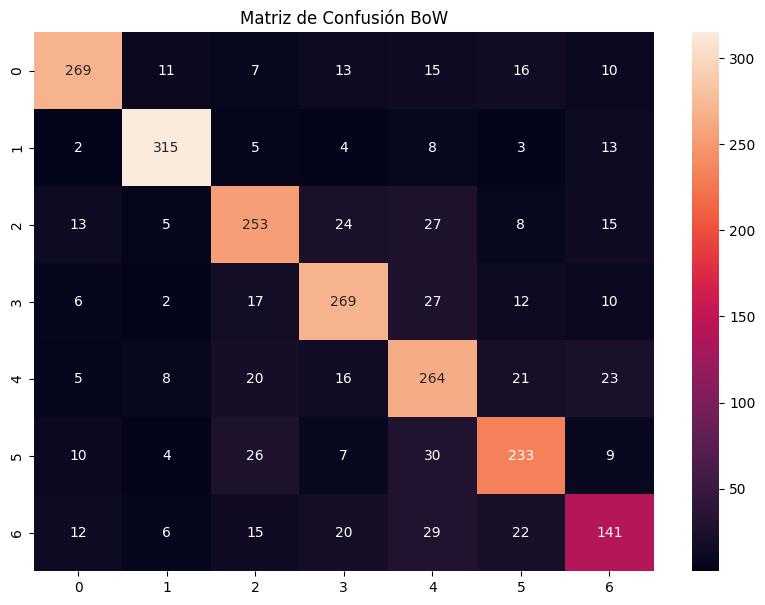

LinearSVC
Resultados para la representación: tfidf
Predicciones: 0.7565217391304347
Classification Report:
              precision    recall  f1-score   support

     cricket       0.85      0.79      0.82       341
    formula1       0.91      0.89      0.90       350
      hockey       0.73      0.72      0.72       345
         nba       0.73      0.78      0.76       343
         nfl       0.69      0.74      0.71       357
      soccer       0.71      0.75      0.73       319
      sports       0.65      0.58      0.61       245

    accuracy                           0.76      2300
   macro avg       0.75      0.75      0.75      2300
weighted avg       0.76      0.76      0.76      2300

Confusion Matrix:


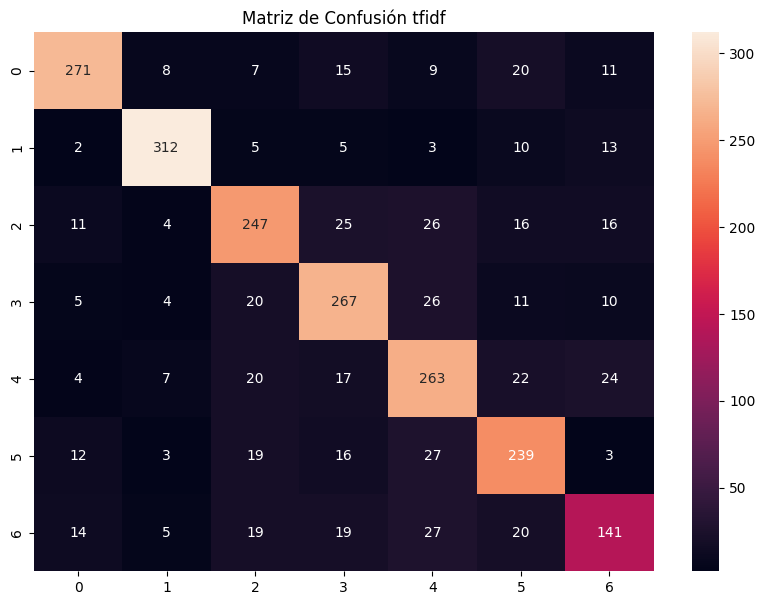

LinearSVC
Resultados para la representación: bm25
Predicciones: 0.7582608695652174
Classification Report:
              precision    recall  f1-score   support

     cricket       0.84      0.79      0.82       341
    formula1       0.91      0.90      0.91       350
      hockey       0.74      0.74      0.74       345
         nba       0.75      0.78      0.76       343
         nfl       0.68      0.73      0.70       357
      soccer       0.73      0.74      0.74       319
      sports       0.63      0.58      0.60       245

    accuracy                           0.76      2300
   macro avg       0.75      0.75      0.75      2300
weighted avg       0.76      0.76      0.76      2300

Confusion Matrix:


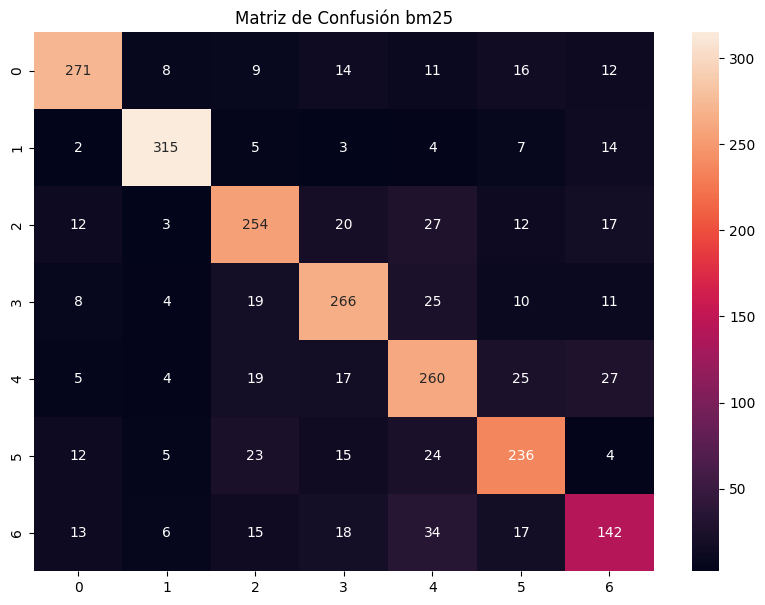

LinearSVC
Resultados para la representación: n_gram
Predicciones: 0.8043478260869565
Classification Report:
              precision    recall  f1-score   support

     cricket       0.83      0.86      0.85       341
    formula1       0.92      0.95      0.93       350
      hockey       0.78      0.77      0.78       345
         nba       0.81      0.83      0.82       343
         nfl       0.73      0.82      0.77       357
      soccer       0.80      0.75      0.78       319
      sports       0.73      0.58      0.65       245

    accuracy                           0.80      2300
   macro avg       0.80      0.79      0.80      2300
weighted avg       0.80      0.80      0.80      2300

Confusion Matrix:


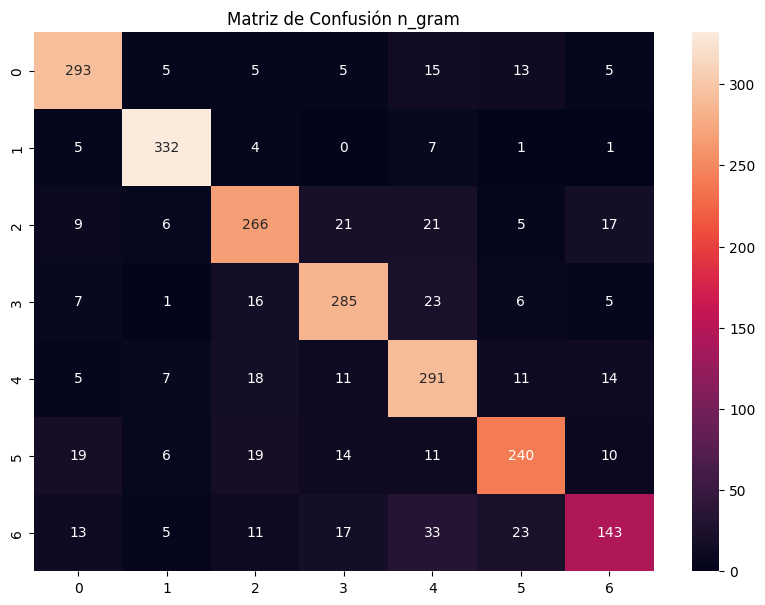

LinearSVC
Resultados para la representación: char_ngram
Predicciones: 0.7817391304347826
Classification Report:
              precision    recall  f1-score   support

     cricket       0.86      0.87      0.87       341
    formula1       0.91      0.92      0.91       350
      hockey       0.75      0.75      0.75       345
         nba       0.78      0.78      0.78       343
         nfl       0.71      0.77      0.74       357
      soccer       0.79      0.74      0.76       319
      sports       0.63      0.57      0.60       245

    accuracy                           0.78      2300
   macro avg       0.77      0.77      0.77      2300
weighted avg       0.78      0.78      0.78      2300

Confusion Matrix:


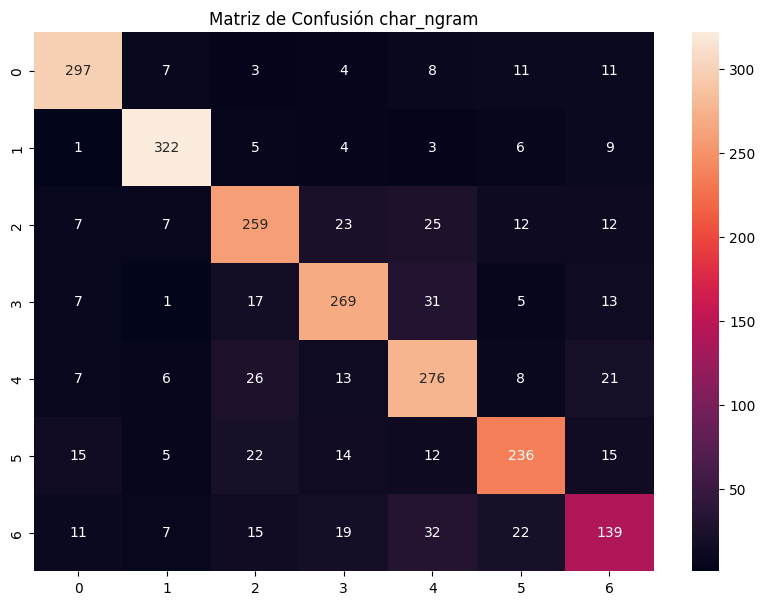

In [15]:
modeloVSrepresentaciones("LinearSVC", results)

Hemos comenzado evaluando el modelo LinearSVC con la representación tradicional Bag of Words (BoW). El clasificador alcanzó una precisión del 75,8%, lo que muestra un rendimiento competitivo considerando la simplicidad de la representación. Las clases **formula1** y **cricket** fueron particularmente bien clasificadas, con f1-scores de 0.90 y 0.82 respectivamente. Sin embargo, categorías como **sports** y **nfl** presentaron un rendimiento más bajo, lo cual indica que el modelo tiene dificultad para distinguir estos subreddits cuando se utilizan representaciones puramente basadas en frecuencia de palabras sin ponderación.

Posteriormente, se aplicó la representación TF-IDF, que mejora la discriminación de términos al penalizar las palabras muy frecuentes en todo el corpus. El rendimiento general fue prácticamente idéntico al de BoW, con una precisión del 75,6%. A nivel de clases, se mantuvieron patrones similares: **formula1** continuó siendo la mejor clasificada, con f1-score de 0.90, mientras que sports mostró resultados modestos (f1-score de 0.61). Esta similitud sugiere que, en este conjunto de datos, TF-IDF no aporta una mejora significativa respecto a BoW, aunque sí ayuda a estabilizar el rendimiento en clases más ambiguas como soccer y nfl.

Con la representación BM25, se esperaban mejoras respecto a TF-IDF, ya que BM25 modela de manera más realista la importancia de los términos en los documentos. Sin embargo, los resultados también se mantuvieron muy similares, con una precisión del 75,8%, exactamente igual que BoW. Las clases formula1 y cricket siguieron mostrando altos valores de f1-score, con 0.91 y 0.82 respectivamente. Aunque BM25 es más sofisticado en su cálculo, esto no se tradujo en una mejora clara en este caso específico, posiblemente porque LinearSVC no se beneficia tanto de los matices de ponderación que BM25 introduce.

Una mejora notable se observó al utilizar n-gramas de palabras, lo cual permitió capturar secuencias frecuentes de términos, proporcionando un contexto adicional. Con esta representación, el clasificador alcanzó una precisión del 80,4%, la más alta entre todas las técnicas tradicionales. Clases como **formula**1 (f1-score de 0.93) y **nba** (f1-score de 0.82) se beneficiaron especialmente, reflejando que estos subreddits presentan frases o expresiones características que los n-gramas permiten capturar mejor. Incluso clases más complicadas como sports mejoraron en precisión, aunque siguen siendo las más difíciles de distinguir.

Por último, se evaluó el uso de char-n-gramas, que descompone el texto en secuencias de caracteres. Esta técnica es útil para capturar morfología o patrones de estilo, y en este caso logró una precisión del 78,2%, quedando por debajo de los n-gramas de palabras, pero por encima de BoW, TF-IDF y BM25. Las clases **cricket** y **formula1** nuevamente fueron las más sólidas (f1-scores de 0.87 y 0.91, respectivamente), mientras que sports mantuvo un rendimiento bajo. Este enfoque parece captar aspectos consistentes en la estructura del lenguaje usado en cada subreddit, aunque no con tanta efectividad como los n-gramas léxicos completos.

En conclusión, las representaciones tradicionales muestran un rendimiento aceptable en la tarea de clasificación de comentarios por subreddit, destacando especialmente el uso de n-gramas de palabras, que ofrece la mayor precisión general. Esto resalta la importancia del contexto y la secuencia de palabras en este tipo de tarea. Por otro lado, las diferencias entre BoW, TF-IDF y BM25 fueron mínimas, lo que sugiere que para este corpus y modelo en particular, las técnicas de ponderación tradicionales no marcan una diferencia considerable.


##  Random Forest

RandomForest
Resultados para la representación: BoW
Predicciones: 0.7734782608695652
Classification Report:
              precision    recall  f1-score   support

     cricket       0.82      0.80      0.81       341
    formula1       0.91      0.92      0.92       350
      hockey       0.81      0.74      0.77       345
         nba       0.77      0.82      0.79       343
         nfl       0.71      0.74      0.72       357
      soccer       0.66      0.79      0.72       319
      sports       0.74      0.54      0.63       245

    accuracy                           0.77      2300
   macro avg       0.77      0.76      0.77      2300
weighted avg       0.78      0.77      0.77      2300

Confusion Matrix:


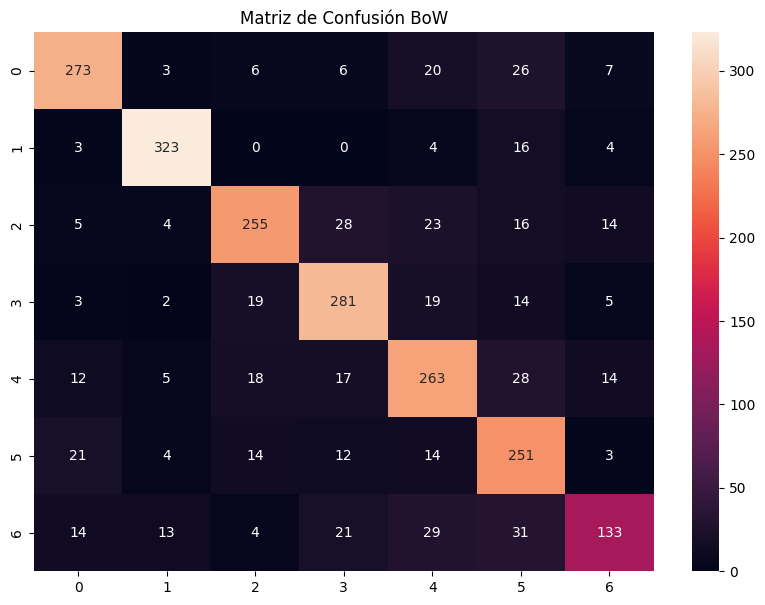

RandomForest
Resultados para la representación: tfidf
Predicciones: 0.7734782608695652
Classification Report:
              precision    recall  f1-score   support

     cricket       0.82      0.80      0.81       341
    formula1       0.91      0.92      0.92       350
      hockey       0.81      0.74      0.77       345
         nba       0.77      0.82      0.79       343
         nfl       0.71      0.74      0.72       357
      soccer       0.66      0.79      0.72       319
      sports       0.74      0.54      0.63       245

    accuracy                           0.77      2300
   macro avg       0.77      0.76      0.77      2300
weighted avg       0.78      0.77      0.77      2300

Confusion Matrix:


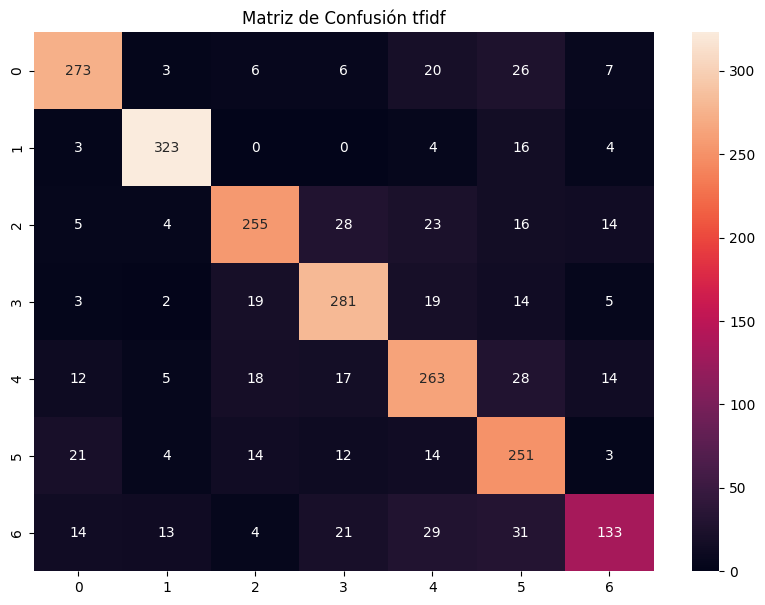

RandomForest
Resultados para la representación: bm25
Predicciones: 0.7682608695652174
Classification Report:
              precision    recall  f1-score   support

     cricket       0.83      0.83      0.83       341
    formula1       0.91      0.93      0.92       350
      hockey       0.79      0.74      0.76       345
         nba       0.78      0.80      0.79       343
         nfl       0.65      0.72      0.68       357
      soccer       0.69      0.76      0.72       319
      sports       0.73      0.53      0.61       245

    accuracy                           0.77      2300
   macro avg       0.77      0.76      0.76      2300
weighted avg       0.77      0.77      0.77      2300

Confusion Matrix:


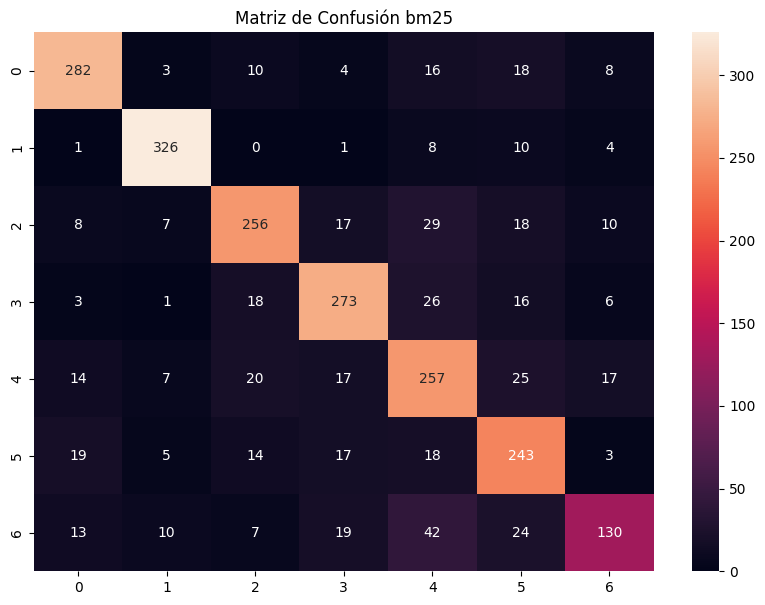

RandomForest
Resultados para la representación: n_gram
Predicciones: 0.7721739130434783
Classification Report:
              precision    recall  f1-score   support

     cricket       0.85      0.81      0.83       341
    formula1       0.89      0.94      0.91       350
      hockey       0.75      0.75      0.75       345
         nba       0.74      0.81      0.77       343
         nfl       0.75      0.71      0.73       357
      soccer       0.67      0.79      0.72       319
      sports       0.79      0.53      0.64       245

    accuracy                           0.77      2300
   macro avg       0.77      0.76      0.76      2300
weighted avg       0.78      0.77      0.77      2300

Confusion Matrix:


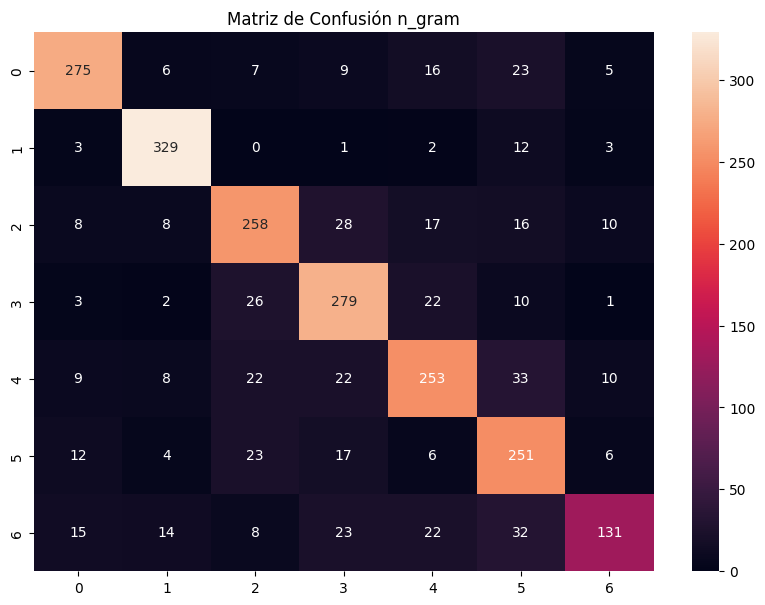

RandomForest
Resultados para la representación: char_ngram
Predicciones: 0.7521739130434782
Classification Report:
              precision    recall  f1-score   support

     cricket       0.83      0.82      0.82       341
    formula1       0.85      0.91      0.88       350
      hockey       0.76      0.72      0.74       345
         nba       0.76      0.77      0.77       343
         nfl       0.62      0.74      0.67       357
      soccer       0.71      0.71      0.71       319
      sports       0.74      0.54      0.62       245

    accuracy                           0.75      2300
   macro avg       0.75      0.74      0.75      2300
weighted avg       0.75      0.75      0.75      2300

Confusion Matrix:


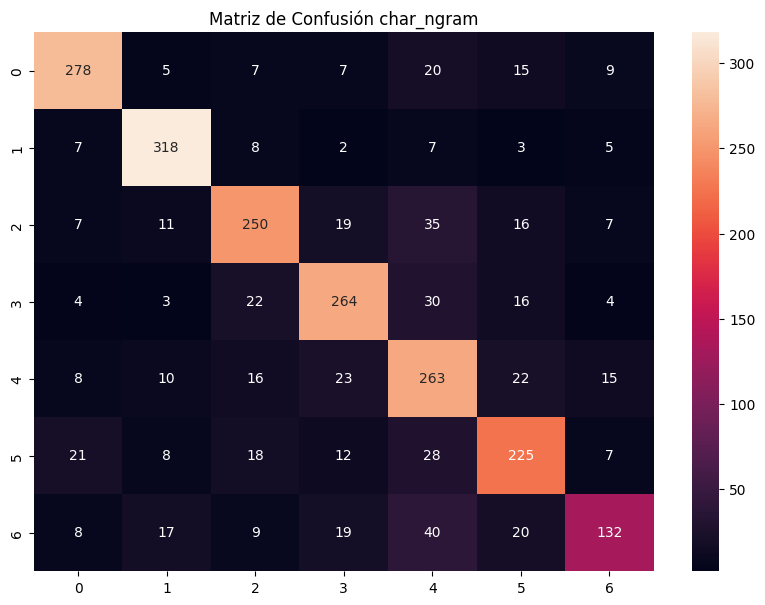

In [16]:
modeloVSrepresentaciones("RandomForest", results)

Con la representación Bag of Words (BoW), Random Forest obtuvo una precisión general del 77,3%, mejorando levemente los resultados que se obtuvieron con LinearSVC en esta misma representación. Las clases mejor clasificadas fueron **formula1** (f1-score de 0.92) y **cricket** (0.81), mientras que sports mostró una caída significativa en el recall (0.54), indicando que el modelo confundió con frecuencia estos comentarios con otras clases. Aun así, el comportamiento general fue robusto, especialmente considerando que BoW es una representación simple que no incluye contexto ni relaciones de orden entre palabras.

La representación TF-IDF, aplicada también con Random Forest, ofreció exactamente los mismos resultados que BoW, tanto en términos de precisión como en cada una de las métricas individuales. Esto sugiere que, al menos para este modelo y conjunto de datos, TF-IDF no aporta una ventaja adicional clara respecto a BoW, replicando exactamente su comportamiento.

Con BM25, la precisión descendió ligeramente hasta 76,8%. Aunque las clases **cricket** y **formula1** mantuvieron un rendimiento elevado (f1-scores de 0.83 y 0.92 respectivamente), otras clases como nfl y sports tuvieron valores de f1 por debajo de 0.70 y 0.61 respectivamente. A pesar de que BM25 mejora la forma de ponderar términos frente a TF-IDF, este tipo de representación parece no ajustarse bien a la arquitectura de Random Forest, posiblemente debido a cómo el modelo maneja la distribución de atributos numéricos.

El uso de n-gramas de palabras no logró la misma mejora observada con LinearSVC. En este caso, Random Forest alcanzó una precisión de 77,2%, ligeramente inferior a BoW y TF-IDF. Aun así, se observó una mayor precisión en clases como **cricket** (0.83) y **formula1** (0.91), mientras que clases ambiguas como sports se mantuvieron con bajo recall (0.53). Esto indica que aunque los n-gramas introducen contexto local, Random Forest no los explota tan eficazmente como lo hace LinearSVC, probablemente porque el número de características aumenta considerablemente y el modelo puede volverse más ruidoso o sobreajustarse.

Por último, con la representación char-n-gramas, se observó el rendimiento más bajo entre las técnicas probadas con Random Forest, alcanzando una precisión del 75,2%. Si bien las clases **formula1** (0.88) y **cricket** (0.82) mantuvieron buenos resultados, otras categorías como nfl, sports y hockey mostraron un rendimiento inferior. El hecho de que los char-n-gramas dividan el texto en secuencias muy pequeñas parece no ser aprovechado completamente por Random Forest, y puede incluso introducir ruido cuando no hay una estrategia clara de selección de características relevantes.

En resumen, el clasificador Random Forest obtiene un rendimiento competitivo y constante en todas las representaciones tradicionales, con una ligera ventaja al usar BoW o TF-IDF. A diferencia de LinearSVC, Random Forest no se beneficia tanto del uso de n-gramas ni de técnicas más sofisticadas como BM25. También se observa que char-n-gramas, aunque útiles en otros modelos, tienden a degradar el rendimiento aquí. La clase **formula1** es sistemáticamente la mejor clasificada, lo cual sugiere que su vocabulario es más distintivo, mientras que sports continúa siendo una clase confusa para todos los modelos y representaciones.

## DecisionTree Classifier

DecisionTree
Resultados para la representación: BoW
Predicciones: 0.6782608695652174
Classification Report:
              precision    recall  f1-score   support

     cricket       0.77      0.69      0.73       341
    formula1       0.87      0.88      0.87       350
      hockey       0.61      0.63      0.62       345
         nba       0.70      0.70      0.70       343
         nfl       0.60      0.62      0.61       357
      soccer       0.60      0.64      0.62       319
      sports       0.56      0.56      0.56       245

    accuracy                           0.68      2300
   macro avg       0.67      0.67      0.67      2300
weighted avg       0.68      0.68      0.68      2300

Confusion Matrix:


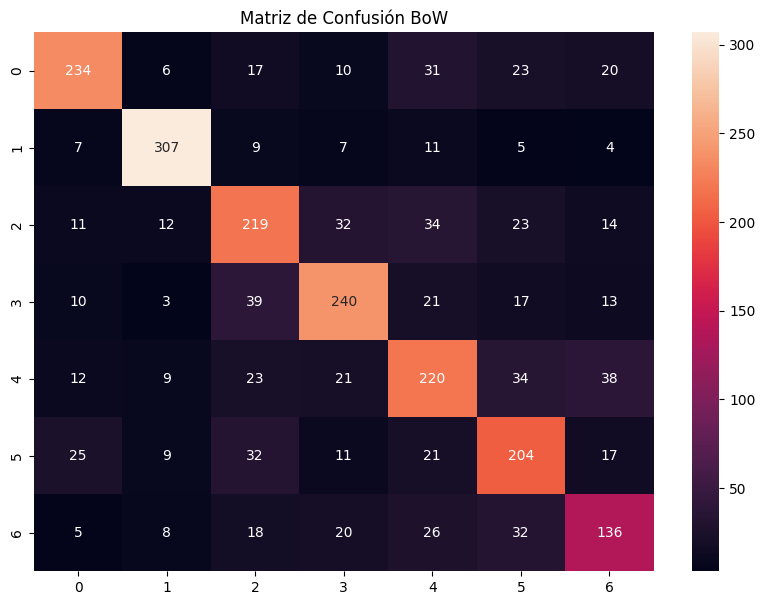

DecisionTree
Resultados para la representación: tfidf
Predicciones: 0.6782608695652174
Classification Report:
              precision    recall  f1-score   support

     cricket       0.77      0.69      0.73       341
    formula1       0.87      0.88      0.87       350
      hockey       0.61      0.63      0.62       345
         nba       0.70      0.70      0.70       343
         nfl       0.60      0.62      0.61       357
      soccer       0.60      0.64      0.62       319
      sports       0.56      0.56      0.56       245

    accuracy                           0.68      2300
   macro avg       0.67      0.67      0.67      2300
weighted avg       0.68      0.68      0.68      2300

Confusion Matrix:


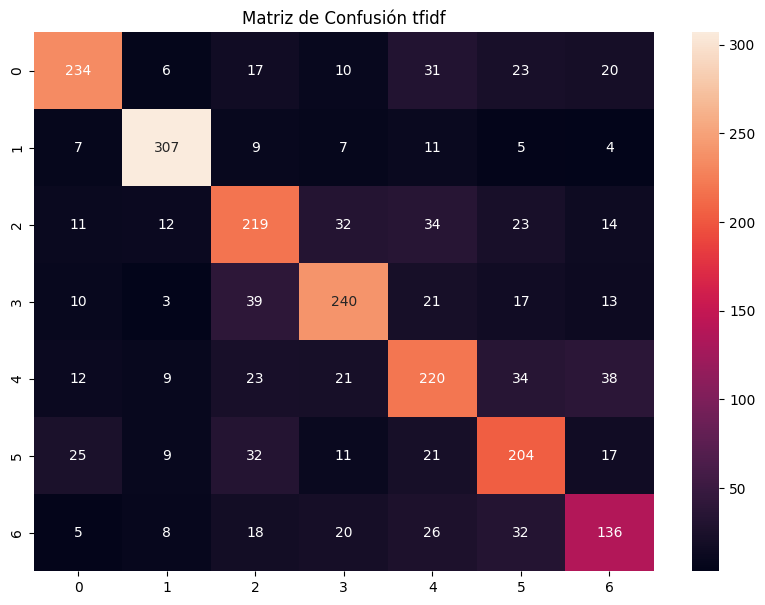

DecisionTree
Resultados para la representación: bm25
Predicciones: 0.67
Classification Report:
              precision    recall  f1-score   support

     cricket       0.70      0.69      0.69       341
    formula1       0.88      0.85      0.86       350
      hockey       0.62      0.63      0.62       345
         nba       0.70      0.72      0.71       343
         nfl       0.61      0.61      0.61       357
      soccer       0.58      0.61      0.60       319
      sports       0.57      0.53      0.55       245

    accuracy                           0.67      2300
   macro avg       0.67      0.66      0.66      2300
weighted avg       0.67      0.67      0.67      2300

Confusion Matrix:


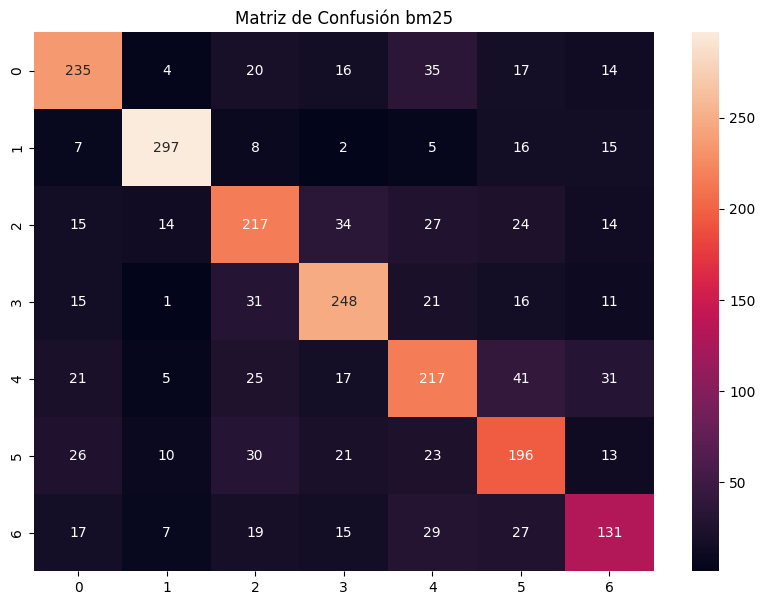

DecisionTree
Resultados para la representación: n_gram
Predicciones: 0.6634782608695652
Classification Report:
              precision    recall  f1-score   support

     cricket       0.70      0.69      0.70       341
    formula1       0.85      0.85      0.85       350
      hockey       0.63      0.64      0.63       345
         nba       0.65      0.70      0.67       343
         nfl       0.65      0.56      0.60       357
      soccer       0.56      0.61      0.58       319
      sports       0.58      0.56      0.57       245

    accuracy                           0.66      2300
   macro avg       0.66      0.66      0.66      2300
weighted avg       0.66      0.66      0.66      2300

Confusion Matrix:


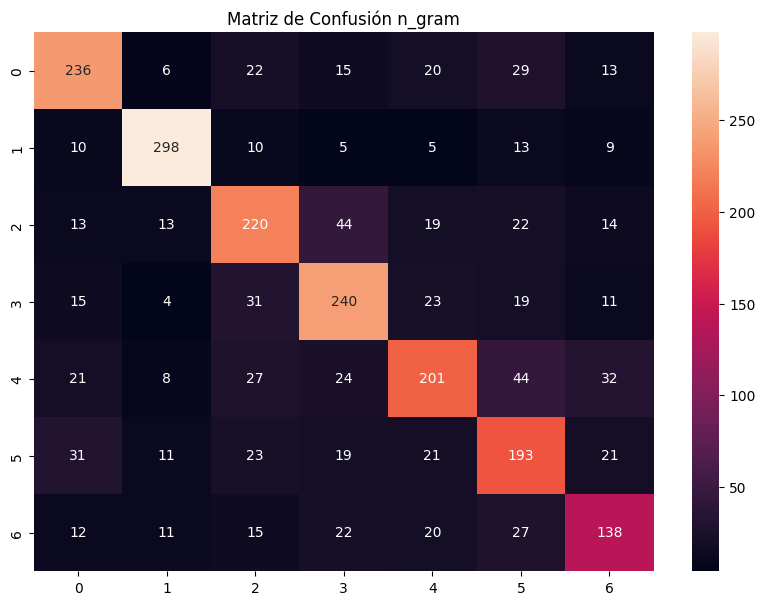

DecisionTree
Resultados para la representación: char_ngram
Predicciones: 0.6269565217391304
Classification Report:
              precision    recall  f1-score   support

     cricket       0.69      0.65      0.67       341
    formula1       0.87      0.81      0.84       350
      hockey       0.55      0.56      0.55       345
         nba       0.62      0.66      0.64       343
         nfl       0.59      0.57      0.58       357
      soccer       0.55      0.56      0.56       319
      sports       0.50      0.56      0.53       245

    accuracy                           0.63      2300
   macro avg       0.63      0.62      0.62      2300
weighted avg       0.63      0.63      0.63      2300

Confusion Matrix:


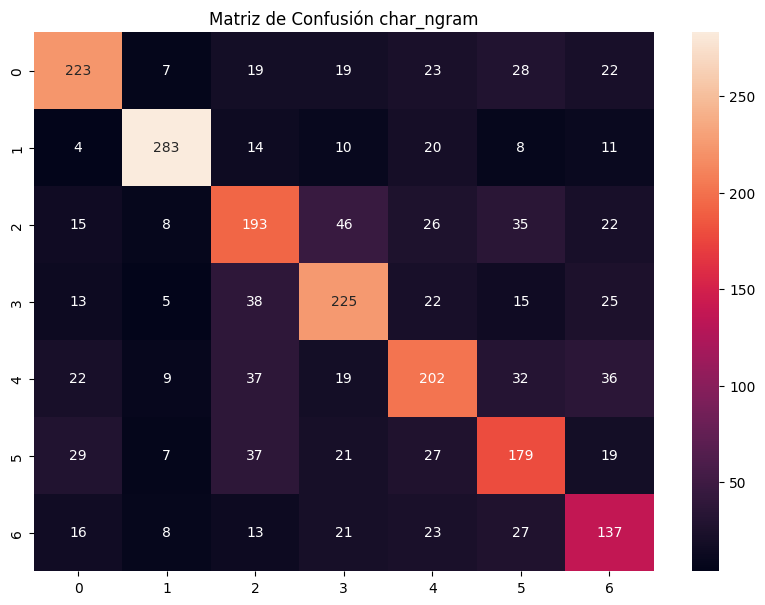

In [17]:
modeloVSrepresentaciones("DecisionTree", results)

La representación Bag of Words (BoW) con árboles de decisión obtuvo una precisión del 67.8%, un rendimiento moderado en comparación con Random Forest o SVM. Las clases **formula1** (f1-score de 0.87) y **cricket** (0.73) se destacaron, mientras que clases más ambiguas como sports (f1-score de 0.56) mostraron dificultades. El modelo parece tener problemas para generalizar bien con clases de vocabulario más disperso o poco distintivo. Este comportamiento es esperado, ya que los árboles de decisión simples tienden a sobreajustarse a los datos de entrenamiento y no suelen manejar bien grandes espacios de características dispersas como ocurre con texto vectorizado.

Con TF-IDF, los resultados fueron idénticos a BoW, lo cual indica que Decision Tree no está aprovechando la información adicional que ofrece TF-IDF en cuanto a la importancia relativa de los términos. Esto podría deberse a que el modelo selecciona divisiones basadas en umbrales simples y no responde bien a diferencias sutiles de ponderación entre características.

En la representación BM25, se observa un ligero descenso en el rendimiento global (precisión del 67.0%). La clase **formula1** sigue siendo la mejor clasificada (f1-score de 0.86), pero la clase sports cae aún más (f1-score de 0.55). Esto refuerza la idea de que Decision Tree tiene dificultad para sacar provecho de representaciones más sofisticadas como BM25, que producen vectores densos con pesos distribuidos de manera más compleja.

Cuando se utilizan n-gramas de palabras, la precisión baja ligeramente a 66.3%. Se mantiene la buena clasificación de **formula1** (0.85), pero otras clases sufren, como nfl (f1-score de 0.60) y soccer (0.58). La inclusión de n-gramas aumenta el número de características, pero este modelo no cuenta con mecanismos efectivos para reducir la dimensionalidad o controlar el sobreajuste, lo cual puede dificultar su rendimiento.

Finalmente, con char-n-gramas, el rendimiento del árbol de decisión es el más bajo de todas las representaciones probadas, con una precisión de apenas 62.7%. Se observa un deterioro en casi todas las clases, con **hockey** y **sports** bajando a f1-scores de 0.55 y 0.53 respectivamente. La representación por caracteres, al generar una enorme cantidad de pequeños fragmentos de texto, introduce ruido que un Decision Tree simple no puede manejar bien, ya que no tiene capacidad de abstracción o reducción de ruido como otros modelos más complejos.

## SVM

SVM
Resultados para la representación: BoW
Predicciones: 0.7430434782608696
Classification Report:
              precision    recall  f1-score   support

     cricket       0.79      0.79      0.79       341
    formula1       0.91      0.88      0.90       350
      hockey       0.69      0.72      0.70       345
         nba       0.73      0.75      0.74       343
         nfl       0.66      0.72      0.69       357
      soccer       0.74      0.72      0.73       319
      sports       0.65      0.58      0.61       245

    accuracy                           0.74      2300
   macro avg       0.74      0.74      0.74      2300
weighted avg       0.74      0.74      0.74      2300

Confusion Matrix:


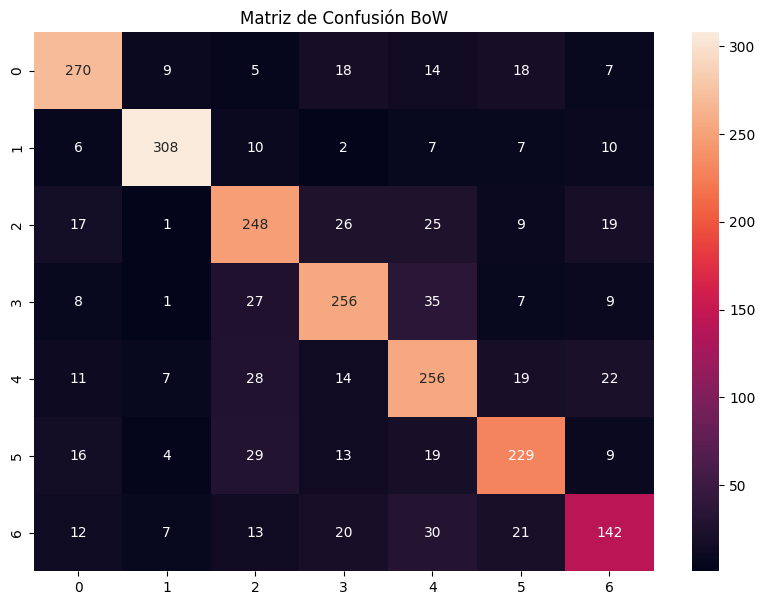

SVM
Resultados para la representación: tfidf
Predicciones: 0.7491304347826087
Classification Report:
              precision    recall  f1-score   support

     cricket       0.81      0.78      0.80       341
    formula1       0.93      0.87      0.90       350
      hockey       0.75      0.72      0.74       345
         nba       0.76      0.76      0.76       343
         nfl       0.69      0.71      0.70       357
      soccer       0.63      0.77      0.69       319
      sports       0.68      0.58      0.62       245

    accuracy                           0.75      2300
   macro avg       0.75      0.74      0.74      2300
weighted avg       0.75      0.75      0.75      2300

Confusion Matrix:


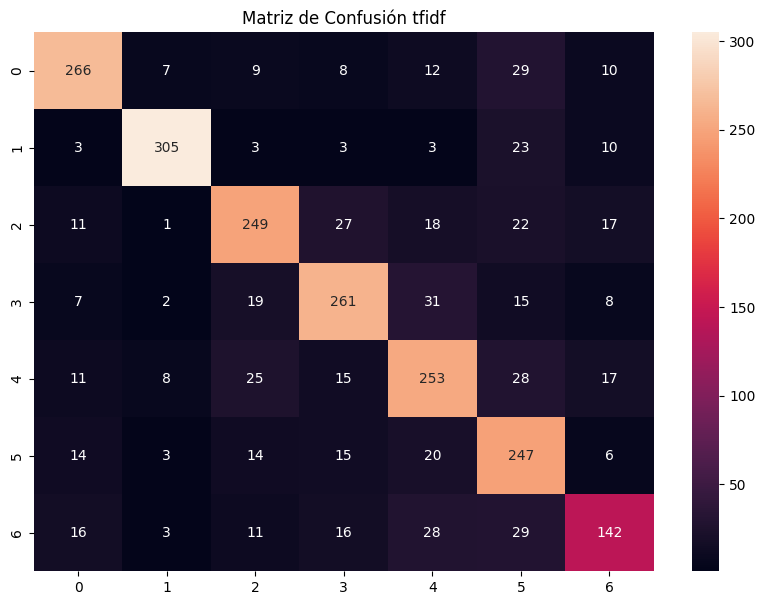

SVM
Resultados para la representación: bm25
Predicciones: 0.7608695652173914
Classification Report:
              precision    recall  f1-score   support

     cricket       0.86      0.79      0.82       341
    formula1       0.92      0.89      0.90       350
      hockey       0.76      0.73      0.75       345
         nba       0.77      0.74      0.76       343
         nfl       0.69      0.74      0.71       357
      soccer       0.65      0.81      0.72       319
      sports       0.68      0.59      0.63       245

    accuracy                           0.76      2300
   macro avg       0.76      0.75      0.76      2300
weighted avg       0.77      0.76      0.76      2300

Confusion Matrix:


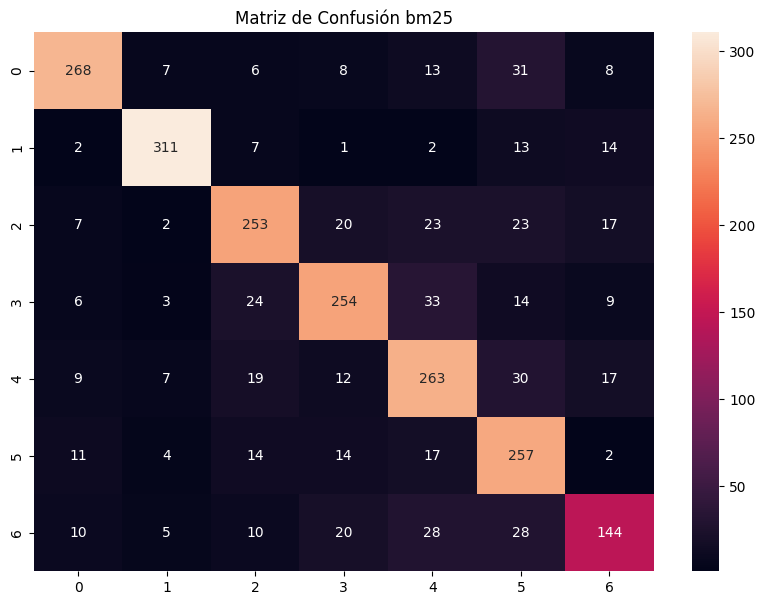

SVM
Resultados para la representación: n_gram
Predicciones: 0.7965217391304348
Classification Report:
              precision    recall  f1-score   support

     cricket       0.89      0.84      0.86       341
    formula1       0.94      0.93      0.94       350
      hockey       0.75      0.78      0.76       345
         nba       0.81      0.82      0.81       343
         nfl       0.67      0.83      0.74       357
      soccer       0.82      0.74      0.78       319
      sports       0.71      0.58      0.64       245

    accuracy                           0.80      2300
   macro avg       0.80      0.79      0.79      2300
weighted avg       0.80      0.80      0.80      2300

Confusion Matrix:


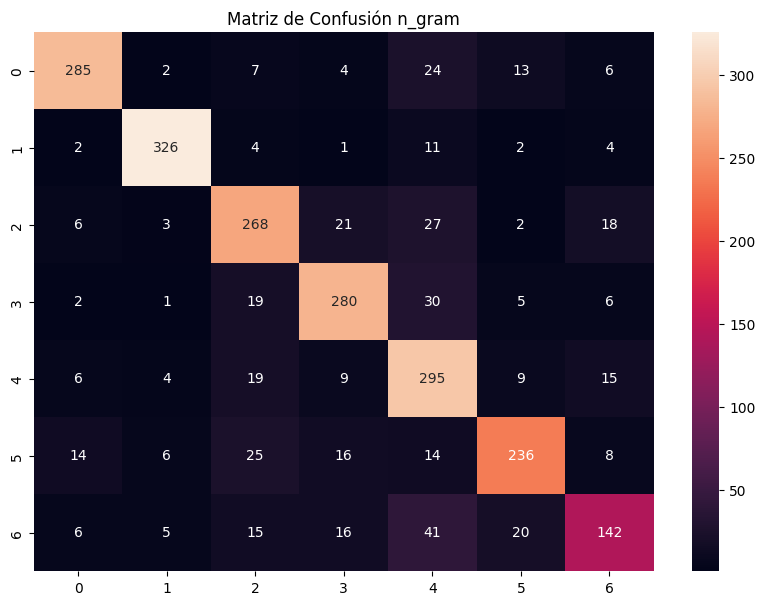

SVM
Resultados para la representación: char_ngram
Predicciones: 0.7578260869565218
Classification Report:
              precision    recall  f1-score   support

     cricket       0.84      0.83      0.84       341
    formula1       0.94      0.87      0.91       350
      hockey       0.73      0.73      0.73       345
         nba       0.80      0.76      0.78       343
         nfl       0.63      0.78      0.69       357
      soccer       0.80      0.72      0.76       319
      sports       0.56      0.55      0.55       245

    accuracy                           0.76      2300
   macro avg       0.76      0.75      0.75      2300
weighted avg       0.77      0.76      0.76      2300

Confusion Matrix:


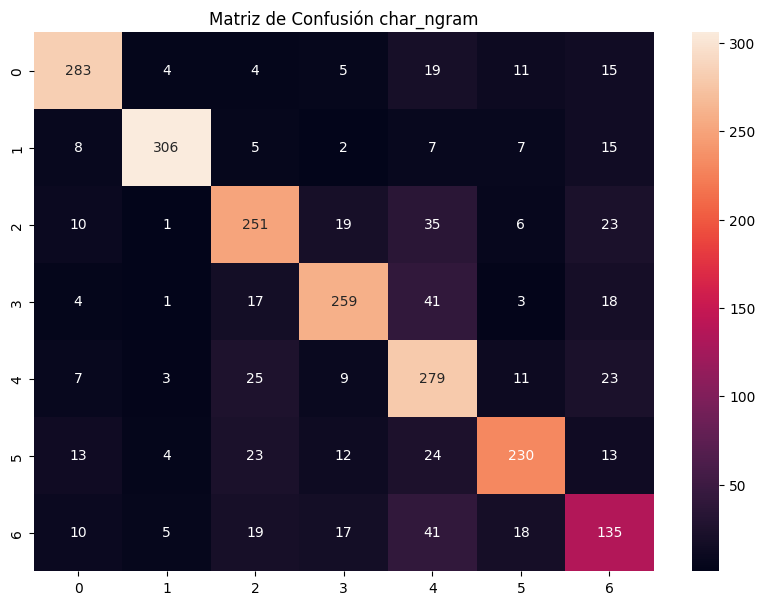

In [18]:
modeloVSrepresentaciones("SVM", results)

El modelo SVM mostró un desempeño general sólido en todas las representaciones, destacándose especialmente con la representación n-gram, donde alcanzó su mayor precisión (accuracy) con un 79.65%. En este caso, las clases mejor clasificadas fueron **formula1** (f1-score de 0.94) y **cricket** (0.86), lo que sugiere que este enfoque captura eficazmente patrones específicos de cada deporte cuando se consideran secuencias de palabras en lugar de términos individuales.

Con la representación BM25, el modelo también logró buenos resultados, alcanzando una precisión del 76.09%. Esta representación parece equilibrar bien la relevancia de los términos, logrando f1-scores altos en **formula1** (0.90), **cricket** (0.82) y **soccer** (0.72). Sin embargo, la clase **sports** continuó siendo difícil de clasificar, con un f1-score de solo 0.63, lo cual podría deberse a que es una categoría más ambigua o genérica.

Por su parte, la representación TF-IDF arrojó una precisión del 74.91%, con un buen desempeño en **formula1** (f1-score de 0.90) y una mejora en la clase **hockey** (0.74). No obstante, la clase **sports** mantuvo un rendimiento bajo (0.62), lo que sugiere que las técnicas basadas en la frecuencia de término no logran capturar toda la variabilidad presente en esa categoría.

La representación BoW (Bag of Words), aunque simple, logró una precisión aceptable de 74.30%, siendo efectiva en las clases **formula1** (0.90) y **cricket** (0.79). Sin embargo, mostró limitaciones para diferenciar correctamente contenidos más genéricos como sports, con un f1-score de solo 0.61, lo que es consistente con el hecho de que BoW ignora el contexto y el orden de las palabras.

Finalmente, con la representación char-ngram, SVM obtuvo una precisión del 75.78%, lo que indica que los patrones de caracteres pueden ser útiles, especialmente para distinguir entre deportes con vocabularios muy característicos. De nuevo, **formula1** fue una de las clases mejor clasificadas (0.91), mientras que **sports** mantuvo el desempeño más bajo (0.55), lo cual refuerza la idea de que esta categoría es más difícil de definir con patrones sintácticos.



# **Modelo 2:** Word Embeddings

En este bloque utilizaremos Word Embeddings para la representación de texto. Para ello, utilizaremos la librería Gensim. Como modelos de Word Embedding fijos vamos a utilizar *Glove*, *FastText*, *Word2Vec* y *Doc2Vec*.

In [20]:
!pip install gensim

In [21]:
train_df_model_2 = apply_preprocessing(train_df, mode="embeddings")
test_df_model_2 = apply_preprocessing(val_df, mode="embeddings")

## GloVe

Obtenemos los archivos pre-entrenados de Glove desde su página oficial https://nlp.stanford.edu/projects/glove/. Vamos a emplear el modelo de 300 dimensiones.

In [22]:
!wget -c --no-check-certificate http://nlp.stanford.edu/data/glove.6B.zip

--2025-05-18 16:02:52--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-05-18 16:02:52--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-05-18 16:02:52--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; not

In [23]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.100d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.200d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace glove.6B.300d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [24]:
!pip install -U numpy
!pip install --force-reinstall --no-cache-dir gensim

# Reiniciamos sesión

  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 11.7 MB/s eta 0:00:00
     ━━

In [25]:
# Cargamos el archivo GloVe de 300 dimensiones
# Gensim no puede leer directamente archivos .txt en formato GloVe. Primero lo convertimos a un formato compatible con KeyedVectors

from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

# Ruta al archivo GloVe
glove_input_file = 'glove.6B.300d.txt'
word2vec_output_file = 'glove.6B.300d.word2vec.txt'

# Convertir el archivo glove a formato word2vec
glove2word2vec(glove_input_file, word2vec_output_file)

# Cargar el modelo con KeyedVectors
model_glove = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)

<ipython-input-25-3c73ced98780>:12: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


Para poder usar GloVe con algoritmos de clasificación como Random Forest o SVM, es necesario transformar cada texto en un vector de longitud fija, ya que GloVe solo proporciona vectores para palabras individuales. Esto se hace generando embeddings de frases o documentos, normalmente calculando el promedio de los vectores GloVe de las palabras que contiene cada texto (conocido como mean pooling). El proceso consiste en tokenizar el texto, obtener el vector de cada palabra si está en el vocabulario de GloVe, y luego calcular la media de todos esos vectores. El resultado final es una matriz de características en la que cada texto está representado por un vector de 300 dimensiones (si se utiliza GloVe de 300d), que puede usarse como entrada para entrenar modelos de clasificación.

In [26]:
# Esta función calcula en un único vector la media aritmética de todos los vectores de tokens
# de un array de textos dado.
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

def gensim_sentence_embeddings(texto, model, idiomaStopWords):
    import nltk
    from nltk.corpus import stopwords
    import numpy as np
#esta función devuelve los sentence embeddings de todos los textos enviados como parámetros
    stopwords_list=stopwords.words(idiomaStopWords)
    # Obtener el número de dimensiones
    num_dimensiones = model.vector_size
    sentence_embeddings = []
    line_vec = []
    tokenized_text = nltk.tokenize.word_tokenize(texto)
    count = 0
    for token in tokenized_text:
       if (token not in stopwords_list):
        # Solamente calculamos los vectores de lo que no son stopwords
        if model.has_index_for(token):
          a = model.get_vector(token)
          if len(line_vec) == 0 :
            line_vec = a
          else:
            line_vec = line_vec + a
          count = count + 1
    if(count>0):
      sentence_embeddings= line_vec/count
    else:
      # Si es 0 devolvemos un array de 0 de las mismas dimensiones
      sentence_embeddings = np.zeros(num_dimensiones)
    return sentence_embeddings

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [27]:
# Convertimos todas las frases de df_train

train_df_model_2['sentence_embeddings_glove'] = train_df_model_2['processed_text'].apply(lambda x: gensim_sentence_embeddings(x, model_glove, 'english'))
train_df_model_2.head()

,text,subreddit,thread_id,processed_text,sentence_embeddings_glove
0,My grandson used to be on the Junior Gators sw...,sports,sports_3,my grandson used to be on the junior gators sw...,"[-0.08772669, 0.10213683, -0.04682395, -0.0790..."
1,Isn't a swimmer this experienced still breakin...,sports,sports_3,isnt a swimmer this experienced still breaking...,"[-0.017487051, 0.06008826, 0.031287443, -0.024..."
2,She beat Summer McIntosh in the 400 a few days...,sports,sports_3,she beat summer mcintosh in the <NUM> a few da...,"[-0.026455842, 0.06017666, 0.13201538, 0.01213..."
3,The best of these is where she’s outta the poo...,sports,sports_3,the best of these is where shes outta the pool...,"[0.11698227, 0.108981915, -0.058975004, -0.052..."
4,Wouldn't be surprised if he didn't even regist...,sports,sports_4,wouldnt be surprised if he didnt even register...,"[0.05001742, 0.18083614, 0.08071092, -0.030558..."


In [28]:
test_df_model_2['sentence_embeddings_glove'] = train_df_model_2['processed_text'].apply(lambda x: gensim_sentence_embeddings(x, model_glove, 'english'))
test_df_model_2.head()

,text,subreddit,thread_id,processed_text,sentence_embeddings_glove
0,That was awesome And those jerseys my god As a...,sports,sports_0,that was awesome and those jerseys my god as a...,"[-0.08772669, 0.10213683, -0.04682395, -0.0790..."
1,Why is scale so hard to figure out here. At a ...,sports,sports_0,why is scale so hard to figure out here at a g...,"[-0.017487051, 0.06008826, 0.031287443, -0.024..."
2,I don't know hockey so excuse the terms e Didn...,sports,sports_0,i dont know hockey so excuse the terms e didnt...,"[-0.026455842, 0.06017666, 0.13201538, 0.01213..."
3,If I was the neighbor I’d research the sound o...,sports,sports_1,if i was the neighbor id research the sound or...,"[0.11698227, 0.108981915, -0.058975004, -0.052..."
4,When i was a kid the neighbor guy was putting ...,sports,sports_1,when i was a kid the neighbor guy was putting ...,"[0.05001742, 0.18083614, 0.08071092, -0.030558..."


Ya tenemos los *sentence embedding* en una columna del DataFrame, el siguiente paso es convertir esos vectores en una matriz Numpy para entrenar los modelos de clasificación:

In [29]:
# Obtenemos los conjuntos X_train, y_train, X_test, y_test
X_train_glove = np.vstack(train_df_model_2['sentence_embeddings_glove'].values)
y_train = train_df_model_2['subreddit']

X_test_glove = np.vstack(test_df_model_2['sentence_embeddings_glove'].values)
y_test = test_df_model_2['subreddit']

## FastText


In [30]:
# Descargamos e importamos la librería fasttext
!pip3 install fasttext
import fasttext

In [31]:
# Descargamos el modelo .bin preentrenado más común en inglés

!wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M-subword.bin.zip
!unzip wiki-news-300d-1M-subword.bin.zip

--2025-05-18 16:08:25--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M-subword.bin.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.108, 3.163.189.14, 3.163.189.51, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4501919899 (4.2G) [application/zip]
Saving to: ‘wiki-news-300d-1M-subword.bin.zip.1’

wiki-news-300d-1M-s 100%[===================>]   4.19G   219MB/s    in 51s     

2025-05-18 16:09:16 (84.1 MB/s) - ‘wiki-news-300d-1M-subword.bin.zip.1’ saved [4501919899/4501919899]

Archive:  wiki-news-300d-1M-subword.bin.zip
replace wiki-news-300d-1M-subword.bin? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [32]:
# Cargamos el modelo con fasttext
model_fasttext = fasttext.load_model('wiki-news-300d-1M-subword.bin')

In [33]:
# Añadimos las sentences embedding de fasttext al DataFrame Original

train_df_model_2['sentence_embeddings_fasttext'] = train_df_model_2['processed_text'].apply(lambda x: model_fasttext.get_sentence_vector(x))
test_df_model_2['sentence_embeddings_fasttext'] = train_df_model_2['processed_text'].apply(lambda x: model_fasttext.get_sentence_vector(x))

# Obtenemos los conjuntos X_train, y_train, X_test, y_test
X_train_fasttext = np.vstack(train_df_model_2['sentence_embeddings_fasttext'].values)
X_test_fasttext = np.vstack(test_df_model_2['sentence_embeddings_fasttext'].values)

## Word2Vec

Para obtener representaciones con Word2Vec, a diferencia de GloVe y FastText que permiten cargar modelos preentrenados, normalmente se entrena el modelo directamente sobre el corpus disponible. Esto permite generar vectores que capturan relaciones semánticas específicas del dominio del conjunto de datos. Entrenar Word2Vec implica procesar el texto (tokenizarlo) y luego usar algoritmos como Skip-gram o CBOW para aprender representaciones vectoriales de las palabras en función de su contexto. Una vez entrenado el modelo, se pueden obtener vectores para cada palabra y construir representaciones de las frases o documentos, por ejemplo, mediante promedios o estrategias más avanzadas.

In [34]:
# Tokenizamos.Procesamos todos los textos y le aplicamos el word_tokenize de NLTK
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
texts = train_df_model_2['processed_text']
train_texts=[]
for text in texts:
     train_texts.append(word_tokenize(text.lower()))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [35]:
from gensim.models import Word2Vec
model = Word2Vec(train_texts, vector_size=300, window=20, min_count=1, workers=10)
print(model)
model.save('model_Word2Vec.bin')

Word2Vec<vocab=13531, vector_size=300, alpha=0.025>


In [36]:
# Cargamos el modelo guardado
model_Word2Vec = Word2Vec.load('model_Word2Vec.bin')
# Probamos el modelo y accedemos al vector de la palabra 'football'
model_Word2Vec.wv['football']

array([-6.17195070e-02,  4.00802195e-01, -3.78858112e-02,  9.79685187e-02,
        1.39204532e-01, -5.53604484e-01,  3.29955846e-01,  7.78700650e-01,
        3.64114866e-02, -1.27505004e-01,  4.90957350e-02, -3.62191461e-02,
       -1.55095924e-02, -1.27664767e-02, -1.83535576e-01, -2.38086805e-01,
        2.67954022e-01, -1.13594770e-01, -7.26104081e-02, -2.46758491e-01,
       -9.50458348e-02, -7.70632029e-02,  2.60254651e-01,  1.15161829e-01,
        2.50399828e-01, -1.26254573e-01, -2.92106748e-01, -1.83144584e-01,
       -3.31650496e-01, -4.30596530e-01,  3.03285122e-01, -2.22584188e-01,
        1.08360201e-01, -9.90380272e-02, -7.08066970e-02,  2.40326449e-01,
        5.57302944e-02, -2.34683573e-01, -6.05143979e-03, -2.16610171e-02,
       -2.33769342e-01, -1.08697906e-01, -8.32597017e-02, -5.32735050e-01,
        3.54366809e-01,  3.65205646e-01,  1.65326878e-01,  2.96231747e-01,
       -1.16775028e-01,  3.99256855e-01,  1.07299075e-01,  6.03010058e-02,
       -4.16973889e-01,  

Ahora que tenemos el modelo *Word2Vec* entrenado, vamos a convertir cada frase en un embedding promediando los vectores de las palabras que aparecen en ella y que están en el vocabulario del modelo:

In [37]:
# Para ello, definimos la siguiente función:
import numpy as np

def sentence_embedding_Word2Vec(text, model):
    words = text.split()
    valid_vectors = [model.wv[word] for word in words if word in model.wv]

    if valid_vectors:
        return np.mean(valid_vectors, axis=0)
    else:
        # Si ninguna palabra está en el vocabulario, devuelves un vector nulo
        return np.zeros(model.vector_size)

# Aplicar a los conjuntos de entrenamiento y test
train_df_model_2['sentence_embeddings_Word2Vec'] = train_df_model_2['processed_text'].apply(lambda x: sentence_embedding_Word2Vec(x, model_Word2Vec))
test_df_model_2['sentence_embeddings_Word2Vec'] = test_df_model_2['processed_text'].apply(lambda x: sentence_embedding_Word2Vec(x, model_Word2Vec))

train_df_model_2['sentence_embeddings_Word2Vec']

,sentence_embeddings_Word2Vec
0,"[-0.13965303, 0.41487047, 0.047120344, 0.09148..."
1,"[-0.07081794, 0.34359086, -0.034945153, 0.0508..."
2,"[-0.15365379, 0.42138234, 0.04432997, 0.063383..."
3,"[-0.09657586, 0.29065698, 0.03110022, 0.036944..."
4,"[-0.18491584, 0.52704257, 0.058611393, 0.11521..."
...,...
5119,"[-0.13575983, 0.41994774, 0.030832252, 0.09153..."
5120,"[-0.15067244, 0.54533184, 0.01011504, 0.142534..."
5121,"[-0.14811222, 0.34307513, 0.075334296, 0.05866..."
5122,"[-0.17506275, 0.38498396, 0.08200834, 0.057652..."


In [38]:
X_train_Word2Vect = np.vstack(train_df_model_2['sentence_embeddings_fasttext'].values)
X_test_Word2Vect = np.vstack(test_df_model_2['sentence_embeddings_fasttext'].values)

## Doc2Vec

In [39]:
# Importamos la librería Doc2Vec
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

#Necestiamos crear un TaggedDocument para cada uno de los textos indicando un índice de cada texto
tagged_data = [TaggedDocument(words=_d, tags=[str(i)]) for i, _d in enumerate(train_texts)]

In [40]:
# Definimos los parámetros de entrenamiento y entrenamos
max_epochs = 5
vec_size = 300
alpha = 0.025

doc2vec_model = Doc2Vec(vector_size=vec_size,
                alpha=alpha,
                min_alpha=0.00025,
                min_count=1,
                dm = 1,
                epochs = max_epochs)

doc2vec_model.build_vocab(tagged_data)  # Esta aprendiendo de forma paralela el embedding y el sentence embedding

for epoch in range(max_epochs):
    doc2vec_model.train(tagged_data,
                total_examples=doc2vec_model.corpus_count,
                epochs=doc2vec_model.epochs)
    # decrease the learning rate
    doc2vec_model.alpha -= 0.0002 # Estamos aplicando momentum
    # fix the learning rate, no decay
    doc2vec_model.min_alpha = model.alpha

doc2vec_model.save("d2v.model")
print("Model Saved")

Model Saved


In [41]:
# Cargamos el modelo y generamos los embedding de entrenamiento y test correspondientes a Word2Vec
doc2vec_model= Doc2Vec.load("d2v.model")

texts = test_df_model_2['processed_text']
test_texts=[]
for text in texts:
     test_texts.append(word_tokenize(text.lower()))

X_train_Doc2Vec = np.array([doc2vec_model.dv[i] for i in range(len(doc2vec_model.dv))])  # Vectores de entrenamiento
X_test_Doc2Vec = np.array([doc2vec_model.infer_vector(text) for text in test_texts])

### Clasificadores

Una vez obtenidas las representaciones vectoriales de las frases a partir de distintos modelos de word embeddings: GloVe, FastText, Word2Vec y Doc2Vec, el siguiente paso consiste en entrenar varios algoritmos de clasificación sobre dichos embeddings para comparar su rendimiento. Los vectores de frases (sentence embeddings) extraídos de cada modelo actúan como características de entrada para los clasificadores. Como en el apartado `Modelo 1`, vamos a aplicar 4 modelos clásicos de clasificación: LinearSVC, RandomForestClassifier, DecisionTreeClassifier y SVM con kernel lineal.

In [42]:
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Ejecutaremos esta función para cada una de las representaciones de este apartado
def train_classifiers(X_train, X_test, y_train, y_test):
    resultados = {}

    # LinearSVC
    lsvc = LinearSVC(random_state=0, tol=1e-5)
    lsvc.fit(X_train, y_train)
    y_pred_lsvc = lsvc.predict(X_test)
    accuracy = np.mean(y_pred_lsvc == y_test)
    resultados["LinearSVC"] = {
        "accuracy": accuracy,
        "report": classification_report(y_test, y_pred_lsvc),
        "confusion_matrix": confusion_matrix(y_test, y_pred_lsvc)
    }

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    accuracy = np.mean(y_pred_rf == y_test)
    resultados["RandomForest"] = {
        "accuracy": accuracy,
        "report": classification_report(y_test, y_pred_rf),
        "confusion_matrix": confusion_matrix(y_test, y_pred_rf)
    }

    # Decision Tree
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    accuracy = np.mean(y_pred_dt == y_test)
    resultados["DecisionTree"] = {
        "accuracy": accuracy,
        "report": classification_report(y_test, y_pred_dt),
        "confusion_matrix": confusion_matrix(y_test, y_pred_dt)
    }

    # SVM con kernel lineal
    svm = SVC(kernel='linear', probability=True, random_state=42)
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test)
    accuracy = np.mean(y_pred_svm == y_test)
    resultados["SVM"] = {
        "accuracy": accuracy,
        "report": classification_report(y_test, y_pred_svm),
        "confusion_matrix": confusion_matrix(y_test, y_pred_svm)
    }

    return resultados

In [43]:
# Aplicamos la función a cada representación
results_glove = train_classifiers(X_train_glove, X_test_glove, y_train, y_test)
results_fasttext = train_classifiers(X_train_fasttext, X_test_fasttext, y_train, y_test)
results_word2vec = train_classifiers(X_train_Word2Vect, X_test_Word2Vect, y_train, y_test)
results_doc2vec = train_classifiers(X_train_Doc2Vec, X_test_Doc2Vec, y_train, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [44]:
# Función para representar los resultados
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

def mostrar_resultados(representacion, results):
  print(f"{representacion}"+"-"*10)
  for model in results:
    print(f"{model}")
    print(f"Accuracy: {results[model]['accuracy']}")
    print(f"Classification Report:")
    print(results[model]['report'])
    # Matriz de confusión
    print("Confusion Matrix:")
    confusion_matrix = results[model]['confusion_matrix']
    df = pd.DataFrame(confusion_matrix)
    plt.figure(figsize=(10, 7))
    sn.heatmap(df, annot=True, fmt="d")
    plt.title(f"Matriz de Confusión")
    plt.show()
    print("\n")

  return

GloVe----------
LinearSVC
Accuracy: 0.09173913043478261
Classification Report:
              precision    recall  f1-score   support

     cricket       0.09      0.02      0.04       341
    formula1       0.03      0.03      0.03       350
      hockey       0.24      0.07      0.11       345
         nba       0.01      0.03      0.02       343
         nfl       0.08      0.04      0.05       357
      soccer       0.05      0.09      0.07       319
      sports       0.38      0.47      0.42       245

    accuracy                           0.09      2300
   macro avg       0.13      0.11      0.10      2300
weighted avg       0.11      0.09      0.09      2300

Confusion Matrix:


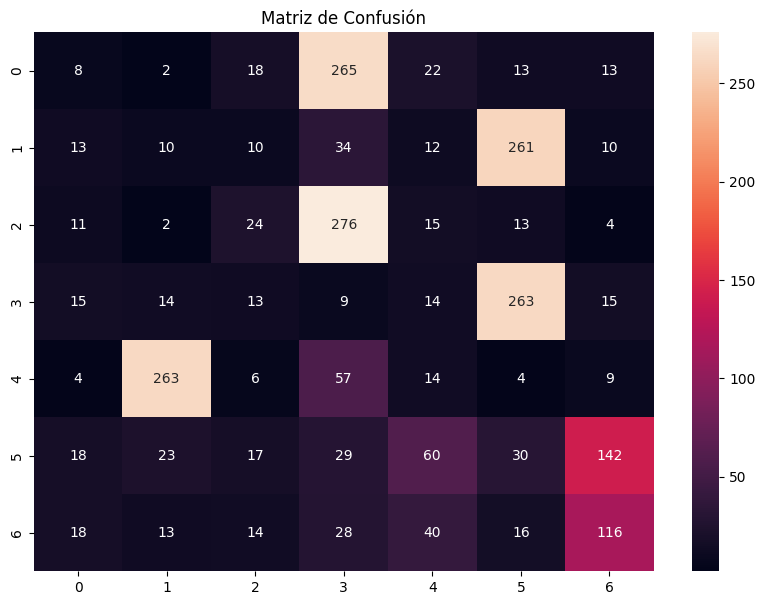



RandomForest
Accuracy: 0.11652173913043479
Classification Report:
              precision    recall  f1-score   support

     cricket       0.00      0.00      0.00       341
    formula1       0.00      0.00      0.00       350
      hockey       0.00      0.00      0.00       345
         nba       0.00      0.00      0.00       343
         nfl       0.00      0.00      0.00       357
      soccer       0.03      0.07      0.05       319
      sports       0.45      1.00      0.62       245

    accuracy                           0.12      2300
   macro avg       0.07      0.15      0.10      2300
weighted avg       0.05      0.12      0.07      2300

Confusion Matrix:


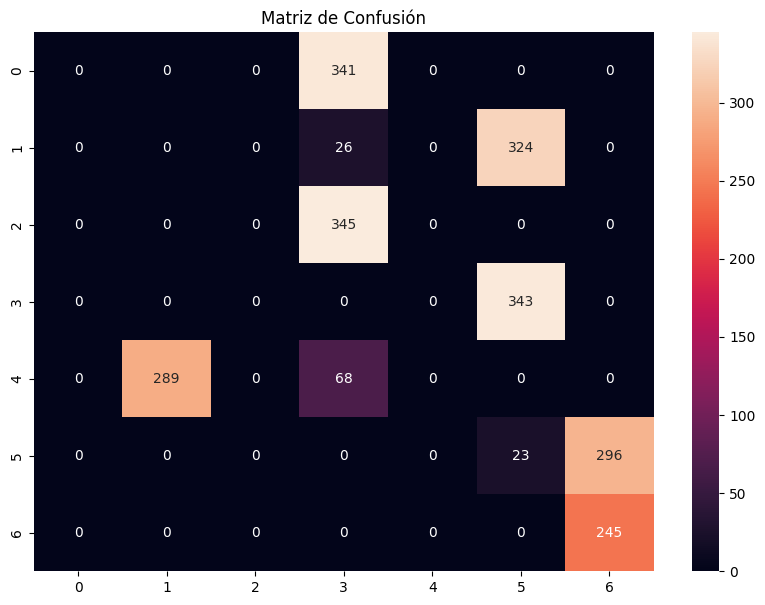



DecisionTree
Accuracy: 0.11652173913043479
Classification Report:
              precision    recall  f1-score   support

     cricket       0.00      0.00      0.00       341
    formula1       0.00      0.00      0.00       350
      hockey       0.00      0.00      0.00       345
         nba       0.00      0.00      0.00       343
         nfl       0.00      0.00      0.00       357
      soccer       0.03      0.07      0.05       319
      sports       0.45      1.00      0.62       245

    accuracy                           0.12      2300
   macro avg       0.07      0.15      0.10      2300
weighted avg       0.05      0.12      0.07      2300

Confusion Matrix:


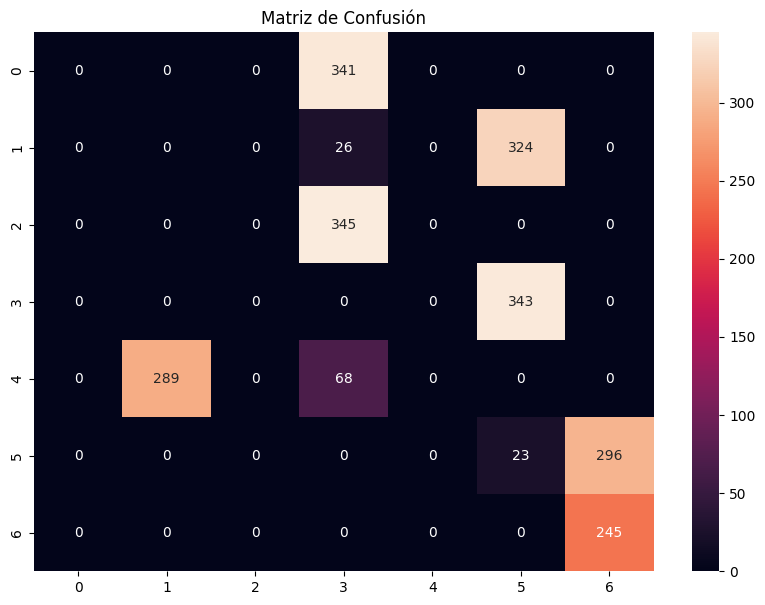



SVM
Accuracy: 0.09913043478260869
Classification Report:
              precision    recall  f1-score   support

     cricket       0.11      0.03      0.04       341
    formula1       0.02      0.02      0.02       350
      hockey       0.27      0.08      0.12       345
         nba       0.01      0.03      0.02       343
         nfl       0.07      0.03      0.04       357
      soccer       0.05      0.10      0.07       319
      sports       0.38      0.54      0.45       245

    accuracy                           0.10      2300
   macro avg       0.13      0.12      0.11      2300
weighted avg       0.12      0.10      0.09      2300

Confusion Matrix:


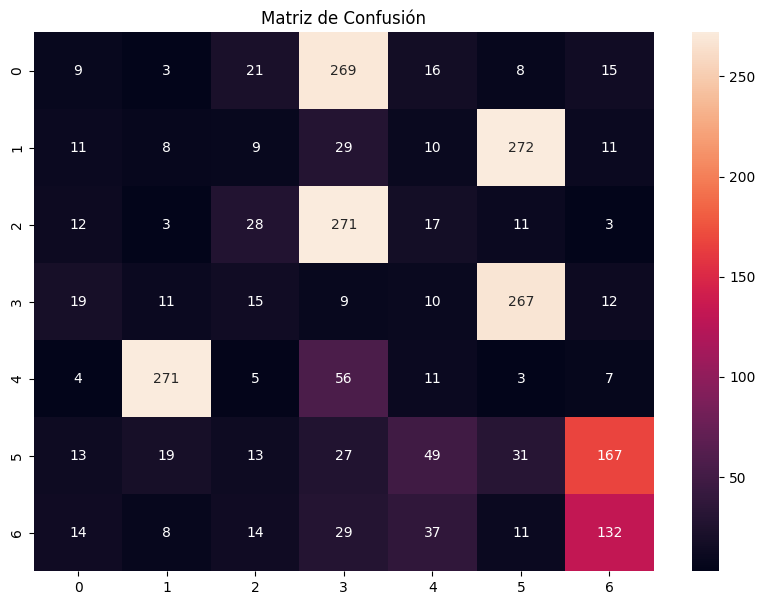

In [45]:
mostrar_resultados("GloVe", results_glove)

Los resultados obtenidos al utilizar representaciones Word Embedding con GloVe (usando sentence embeddings) fueron considerablemente inferiores en comparación con otras representaciones previamente exploradas como BoW, TF-IDF o BM25. Esto se refleja en el bajo rendimiento de todos los modelos de clasificación aplicados. El modelo LinearSVC alcanzó una precisión de apenas 9.17%, evidenciando que no logró capturar patrones útiles para discriminar entre las clases del conjunto de datos. A pesar de que algunas clases, como **sports**, tuvieron un rendimiento aceptable en términos de recall (0.47), el resto mostró valores muy bajos, lo que indica una pobre capacidad generalizadora del modelo con esta representación.

Por su parte, los modelos Random Forest y Decision Tree obtuvieron exactamente la misma precisión, 11.65%, lo que puede sugerir que ambos clasificadores aprendieron principalmente a identificar la clase **sports**, mientras que ignoraron o no supieron distinguir el resto de las categorías. Esto se refuerza con los valores de recall perfectos (1.00) para la clase sports, lo que indica que esos modelos simplemente asignaban muchas predicciones a esa clase, posiblemente por un sesgo generado por la estructura de los embeddings o una alta similitud semántica en las oraciones.

El modelo SVM también tuvo un desempeño limitado, con una precisión de 9.91%, sin mostrar una mejora significativa respecto a los demás modelos. Al igual que en el caso anterior, destaca un f1-score relativamente alto solo para la clase **sports**, pero un desempeño muy pobre en las demás clases. Este comportamiento sugiere que los sentence embeddings generados con GloVe no fueron capaces de preservar suficiente información discriminativa para la tarea de clasificación multiclase en el dominio de noticias deportivas.


Fasttext----------
LinearSVC
Accuracy: 0.09173913043478261
Classification Report:
              precision    recall  f1-score   support

     cricket       0.15      0.06      0.09       341
    formula1       0.05      0.06      0.05       350
      hockey       0.23      0.08      0.12       345
         nba       0.02      0.03      0.02       343
         nfl       0.06      0.04      0.05       357
      soccer       0.05      0.09      0.07       319
      sports       0.35      0.35      0.35       245

    accuracy                           0.09      2300
   macro avg       0.13      0.10      0.11      2300
weighted avg       0.12      0.09      0.10      2300

Confusion Matrix:


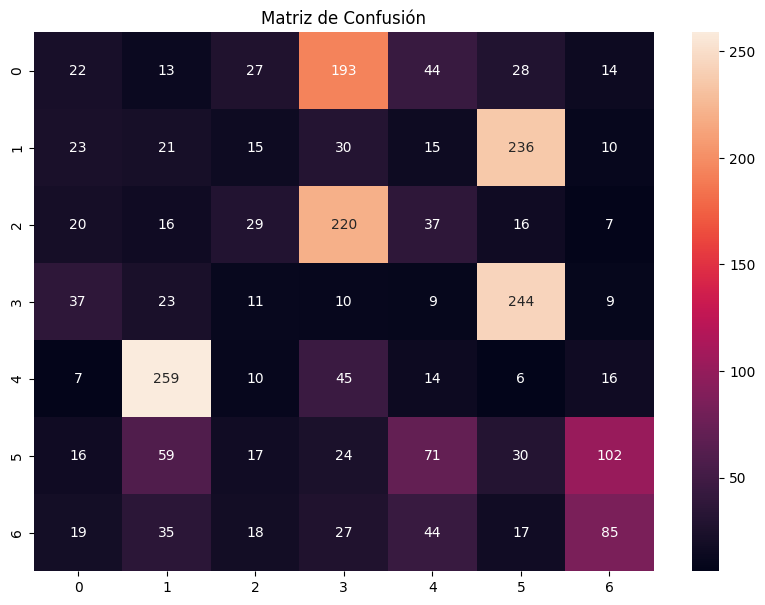



RandomForest
Accuracy: 0.11652173913043479
Classification Report:
              precision    recall  f1-score   support

     cricket       0.00      0.00      0.00       341
    formula1       0.00      0.00      0.00       350
      hockey       0.00      0.00      0.00       345
         nba       0.00      0.00      0.00       343
         nfl       0.00      0.00      0.00       357
      soccer       0.03      0.07      0.05       319
      sports       0.45      1.00      0.62       245

    accuracy                           0.12      2300
   macro avg       0.07      0.15      0.10      2300
weighted avg       0.05      0.12      0.07      2300

Confusion Matrix:


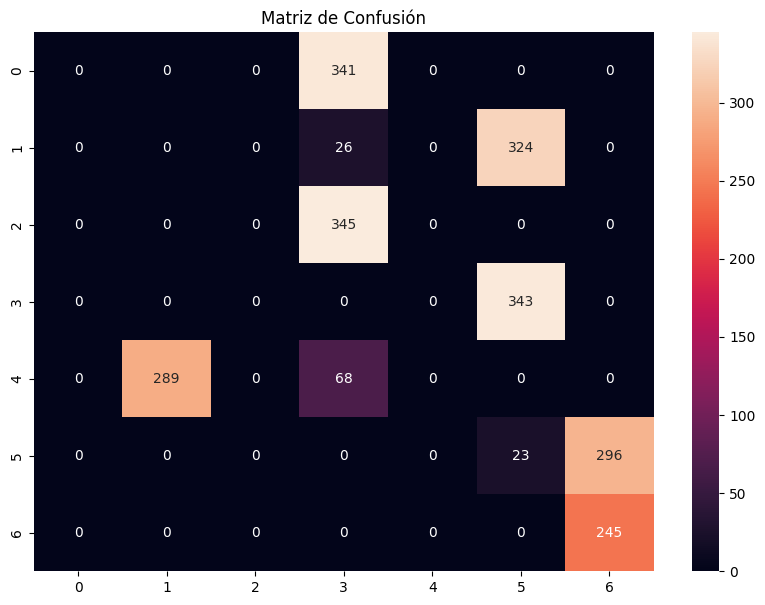



DecisionTree
Accuracy: 0.11652173913043479
Classification Report:
              precision    recall  f1-score   support

     cricket       0.00      0.00      0.00       341
    formula1       0.00      0.00      0.00       350
      hockey       0.00      0.00      0.00       345
         nba       0.00      0.00      0.00       343
         nfl       0.00      0.00      0.00       357
      soccer       0.03      0.07      0.05       319
      sports       0.45      1.00      0.62       245

    accuracy                           0.12      2300
   macro avg       0.07      0.15      0.10      2300
weighted avg       0.05      0.12      0.07      2300

Confusion Matrix:


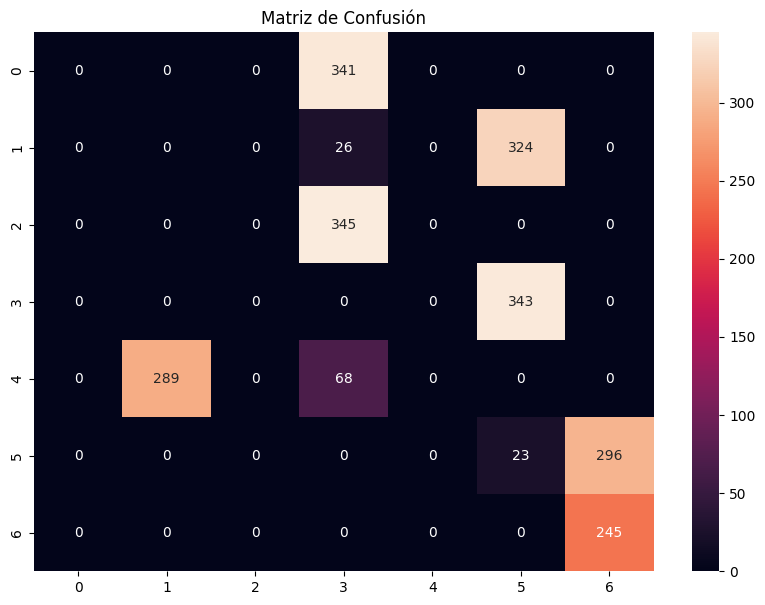



SVM
Accuracy: 0.09434782608695652
Classification Report:
              precision    recall  f1-score   support

     cricket       0.12      0.05      0.07       341
    formula1       0.10      0.18      0.13       350
      hockey       0.08      0.01      0.02       345
         nba       0.15      0.08      0.10       343
         nfl       0.09      0.30      0.13       357
      soccer       0.02      0.01      0.01       319
      sports       0.00      0.00      0.00       245

    accuracy                           0.09      2300
   macro avg       0.08      0.09      0.07      2300
weighted avg       0.08      0.09      0.07      2300

Confusion Matrix:


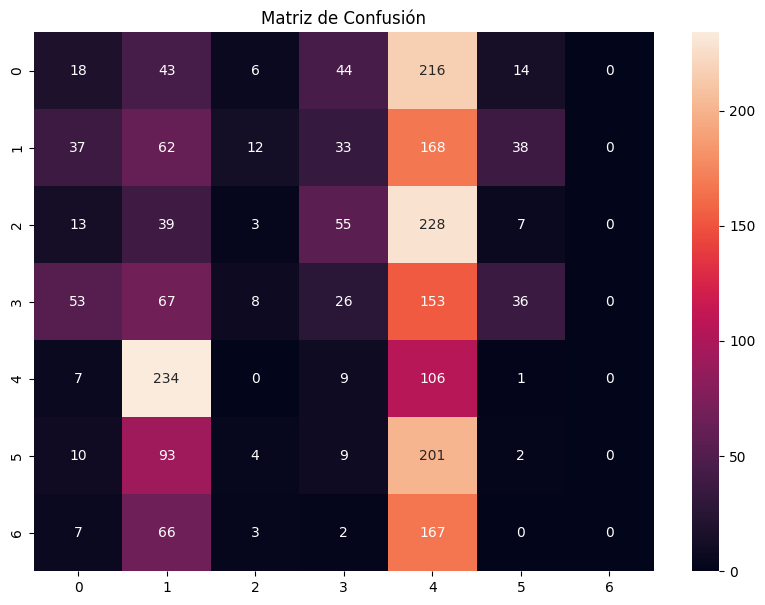

In [46]:
mostrar_resultados("Fasttext", results_fasttext)

Los resultados con representaciones basadas en FastText fueron considerablemente bajos para todos los modelos. Random Forest y Decision Tree alcanzaron una precisión del 11.65%, pero predijeron casi exclusivamente la clase **sports**. LinearSVC y SVM apenas superaron el 9% de precisión, mostrando un rendimiento deficiente y un fuerte sesgo en las predicciones. Esto indica que, al igual que con GloVe, las embeddings de FastText no proporcionaron suficiente discriminación semántica para esta tarea multiclase, al menos en la forma en que fueron utilizadas.

Word2Vec----------
LinearSVC
Accuracy: 0.09173913043478261
Classification Report:
              precision    recall  f1-score   support

     cricket       0.15      0.06      0.09       341
    formula1       0.05      0.06      0.05       350
      hockey       0.23      0.08      0.12       345
         nba       0.02      0.03      0.02       343
         nfl       0.06      0.04      0.05       357
      soccer       0.05      0.09      0.07       319
      sports       0.35      0.35      0.35       245

    accuracy                           0.09      2300
   macro avg       0.13      0.10      0.11      2300
weighted avg       0.12      0.09      0.10      2300

Confusion Matrix:


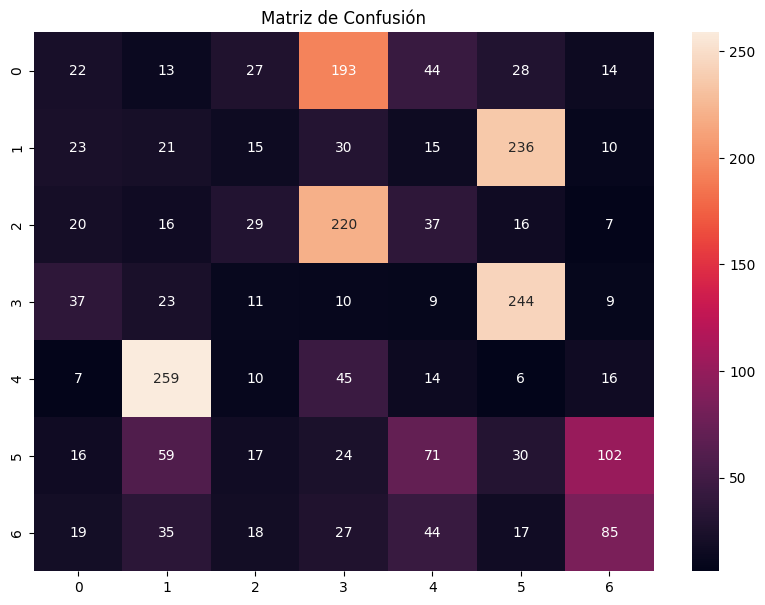



RandomForest
Accuracy: 0.11652173913043479
Classification Report:
              precision    recall  f1-score   support

     cricket       0.00      0.00      0.00       341
    formula1       0.00      0.00      0.00       350
      hockey       0.00      0.00      0.00       345
         nba       0.00      0.00      0.00       343
         nfl       0.00      0.00      0.00       357
      soccer       0.03      0.07      0.05       319
      sports       0.45      1.00      0.62       245

    accuracy                           0.12      2300
   macro avg       0.07      0.15      0.10      2300
weighted avg       0.05      0.12      0.07      2300

Confusion Matrix:


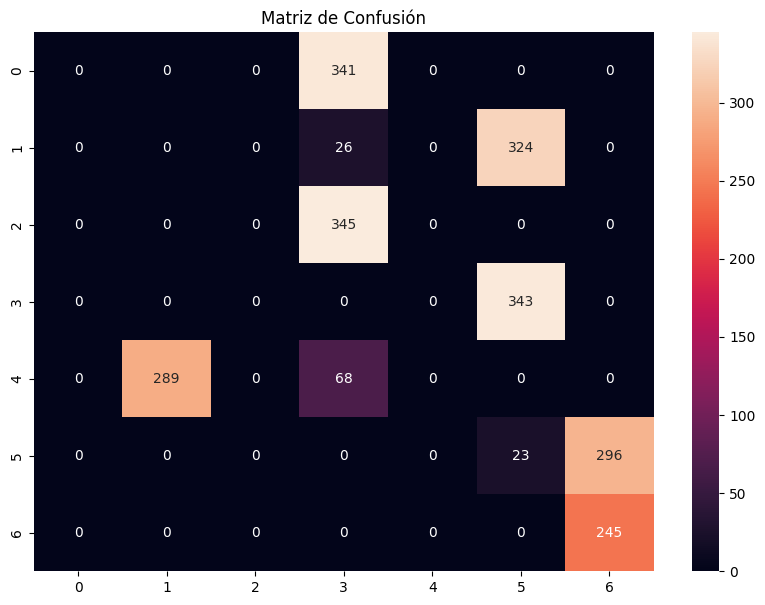



DecisionTree
Accuracy: 0.11652173913043479
Classification Report:
              precision    recall  f1-score   support

     cricket       0.00      0.00      0.00       341
    formula1       0.00      0.00      0.00       350
      hockey       0.00      0.00      0.00       345
         nba       0.00      0.00      0.00       343
         nfl       0.00      0.00      0.00       357
      soccer       0.03      0.07      0.05       319
      sports       0.45      1.00      0.62       245

    accuracy                           0.12      2300
   macro avg       0.07      0.15      0.10      2300
weighted avg       0.05      0.12      0.07      2300

Confusion Matrix:


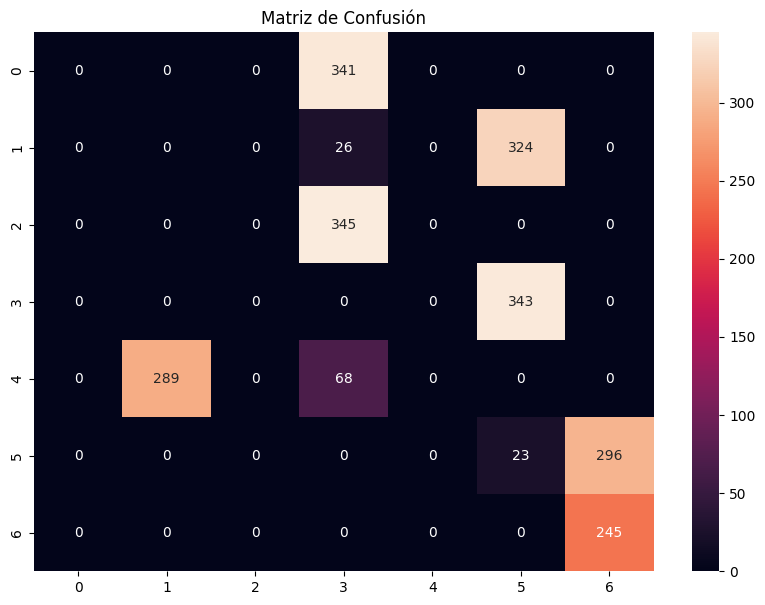



SVM
Accuracy: 0.09434782608695652
Classification Report:
              precision    recall  f1-score   support

     cricket       0.12      0.05      0.07       341
    formula1       0.10      0.18      0.13       350
      hockey       0.08      0.01      0.02       345
         nba       0.15      0.08      0.10       343
         nfl       0.09      0.30      0.13       357
      soccer       0.02      0.01      0.01       319
      sports       0.00      0.00      0.00       245

    accuracy                           0.09      2300
   macro avg       0.08      0.09      0.07      2300
weighted avg       0.08      0.09      0.07      2300

Confusion Matrix:


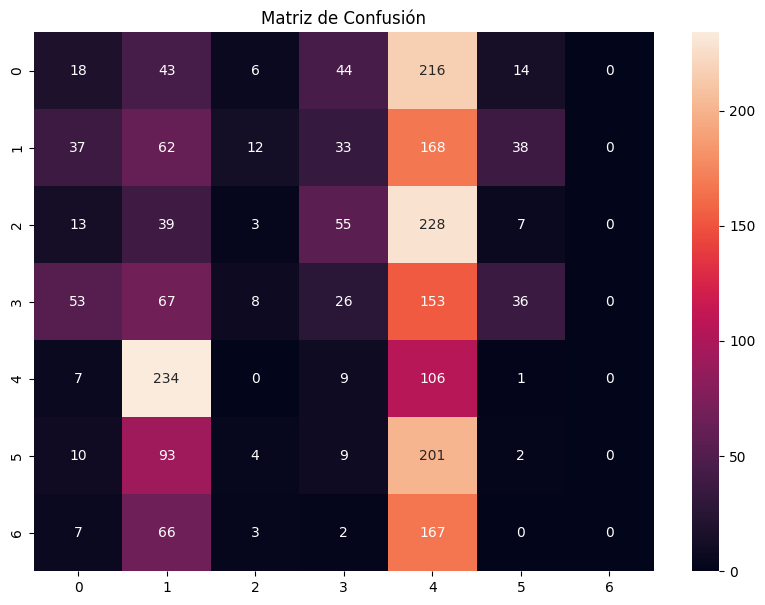

In [47]:
mostrar_resultados("Word2Vec", results_word2vec)

Los resultados obtenidos con Word2Vec fueron también bastante bajos en todos los modelos evaluados. LinearSVC y SVM apenas alcanzaron una precisión del 9%, mostrando una clasificación muy pobre y dispersa entre las clases. Random Forest y Decision Tree repitieron el patrón visto con otras embeddings, alcanzando solo el 11.65% de precisión y concentrando sus aciertos casi exclusivamente en la clase **sports**.










Doc2Vec----------
LinearSVC
Accuracy: 0.41347826086956524
Classification Report:
              precision    recall  f1-score   support

     cricket       0.51      0.42      0.46       341
    formula1       0.58      0.74      0.65       350
      hockey       0.36      0.29      0.32       345
         nba       0.31      0.68      0.43       343
         nfl       0.51      0.17      0.26       357
      soccer       0.36      0.42      0.39       319
      sports       0.40      0.07      0.12       245

    accuracy                           0.41      2300
   macro avg       0.43      0.40      0.38      2300
weighted avg       0.44      0.41      0.39      2300

Confusion Matrix:


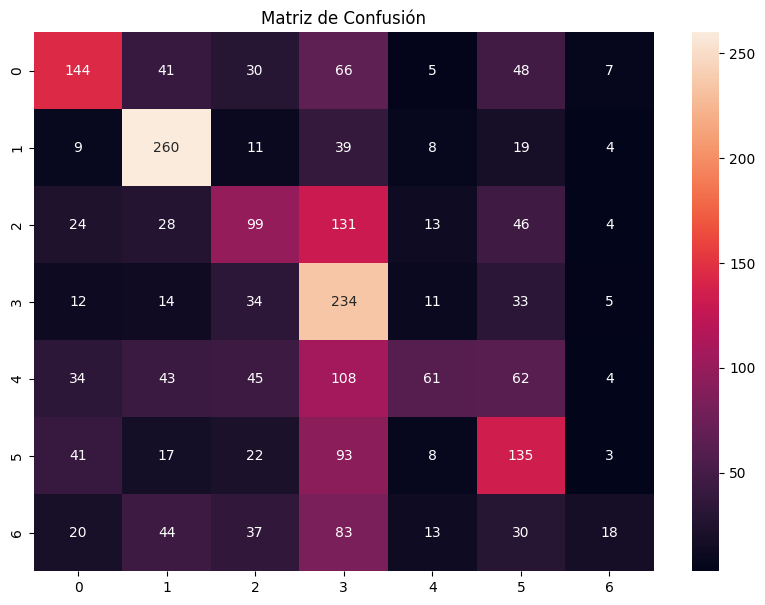



RandomForest
Accuracy: 0.26130434782608697
Classification Report:
              precision    recall  f1-score   support

     cricket       0.48      0.06      0.10       341
    formula1       0.53      0.48      0.50       350
      hockey       0.20      0.16      0.18       345
         nba       0.24      0.51      0.33       343
         nfl       0.27      0.05      0.08       357
      soccer       0.18      0.51      0.27       319
      sports       0.38      0.02      0.04       245

    accuracy                           0.26      2300
   macro avg       0.33      0.25      0.21      2300
weighted avg       0.33      0.26      0.22      2300

Confusion Matrix:


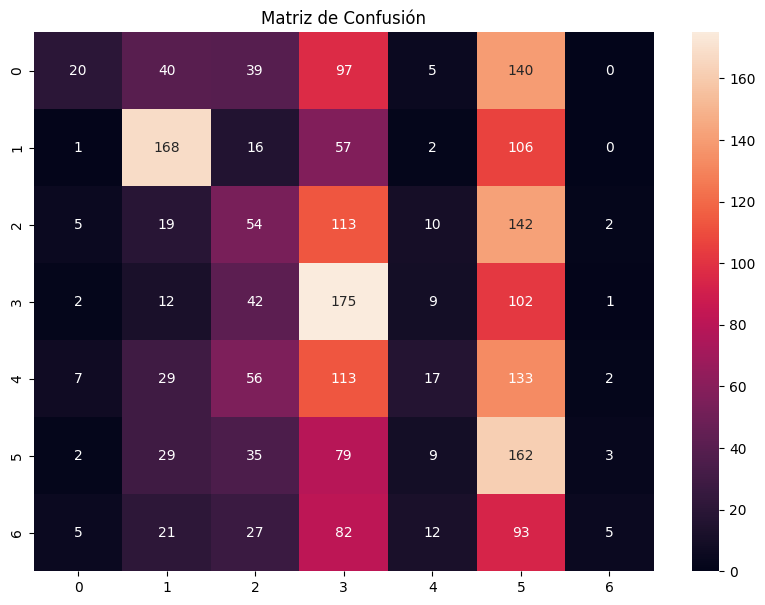



DecisionTree
Accuracy: 0.1991304347826087
Classification Report:
              precision    recall  f1-score   support

     cricket       0.21      0.12      0.15       341
    formula1       0.33      0.28      0.31       350
      hockey       0.16      0.19      0.17       345
         nba       0.20      0.22      0.21       343
         nfl       0.20      0.17      0.18       357
      soccer       0.17      0.27      0.21       319
      sports       0.15      0.14      0.15       245

    accuracy                           0.20      2300
   macro avg       0.20      0.20      0.20      2300
weighted avg       0.21      0.20      0.20      2300

Confusion Matrix:


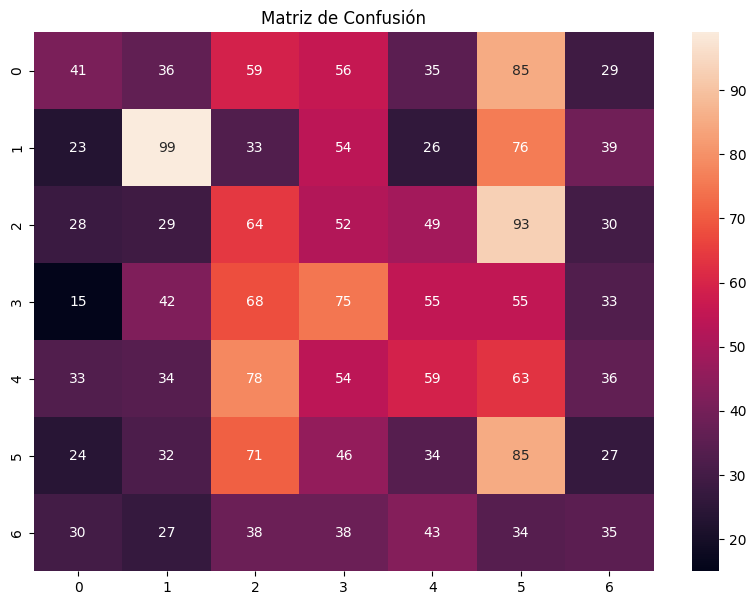



SVM
Accuracy: 0.3591304347826087
Classification Report:
              precision    recall  f1-score   support

     cricket       0.55      0.21      0.30       341
    formula1       0.70      0.54      0.61       350
      hockey       0.29      0.34      0.32       345
         nba       0.30      0.73      0.43       343
         nfl       0.40      0.10      0.15       357
      soccer       0.29      0.39      0.33       319
      sports       0.28      0.15      0.20       245

    accuracy                           0.36      2300
   macro avg       0.40      0.35      0.33      2300
weighted avg       0.41      0.36      0.34      2300

Confusion Matrix:


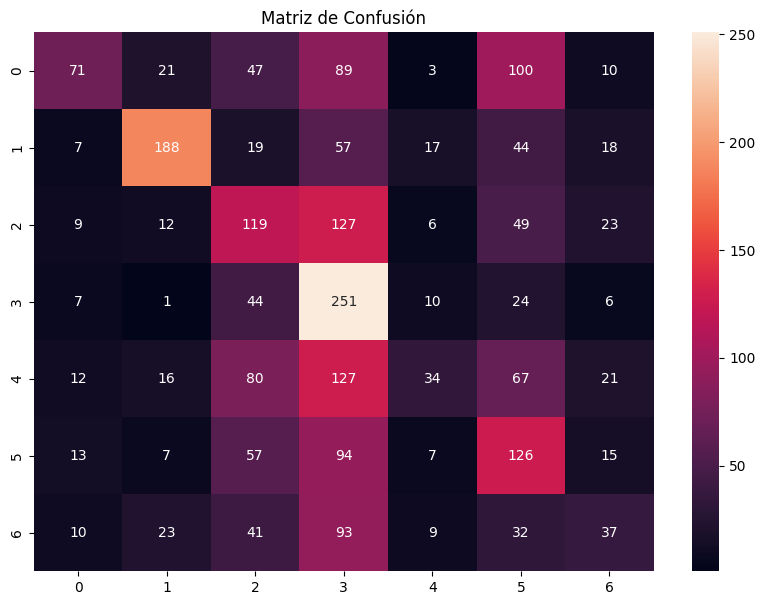

In [48]:
mostrar_resultados("Doc2Vec", results_doc2vec)

Los resultados obtenidos con Doc2Vec muestran un rendimiento moderado en comparación con otras representaciones vectoriales como Word2Vec o FastText. El mejor desempeño se observó con el modelo LinearSVC, que alcanzó una precisión del 41.3%, seguido por SVM con un 35.9%. Ambos modelos lograron identificar algunas clases con relativa efectividad, especialmente **formula1** y **nba**, aunque otras como sports o nfl presentaron bajos niveles de recall. Por su parte, Random Forest y Decision Tree ofrecieron resultados considerablemente inferiores, con precisiones del 26.1% y 19.9% respectivamente. En general, Doc2Vec logró representar mejor los documentos que otras técnicas basadas en embeddings densos, pero aún queda muy por debajo del rendimiento alcanzado por enfoques basados en n-gramas o BM25.

Con estos resultados comprobamos que las técnicas basadas en frecuencias de palabras suelen superar a los embeddings como Glove, FastText, Word2Vec y Doc2Vec en tareas específicas de clasificación de texto porque capturan directamente la presencia y frecuencia de términos importantes y patrones locales en el texto, lo que resulta muy efectivo para distinguir categorías cuando las palabras clave y combinaciones de palabras son indicadores claros. TF-IDF resalta términos distintivos, mientras que los n-gramas capturan contextos y combinaciones de palabras que mejoran la discriminación, y BM25 ajusta la relevancia considerando la frecuencia y longitud del documento. Por otro lado, los embeddings densos como Doc2Vec han mostrado mejores resultados que los demás porque genera mejores representaciones a nivel de documento que los otros embeddings, permitiendo capturar contextos más amplios y específicos del texto completo, aunque aún no alcanza la eficacia de los métodos basados en frecuencia para esta tarea concreta.










# **Modelo 3:** Transformer (BERT)

En esta parte de la práctica abordamos el fine-tuning de un modelo Transformer preentrenado utilizando la librería Hugging Face Transformers, con el objetivo de adaptarlo a una tarea específica de clasificación de texto. Los modelos Transformers, como BERT, RoBERTa, BETO, MarIA o mDeBERTa, han sido previamente entrenados sobre grandes corpus de texto mediante tareas como la predicción de palabras enmascaradas (Masked Language Modeling, MLM), lo que les permite aprender representaciones profundas y contextualizadas del lenguaje.

Dado que nuestro corpus está en inglés, optamos por el modelo BERT base uncased (bert-base-uncased), ampliamente utilizado y optimizado para tareas de procesamiento de lenguaje natural en dicho idioma. Este modelo se basa únicamente en la arquitectura de codificadores (encoders), lo que le permite capturar de forma eficiente relaciones complejas entre palabras dentro de una oración. Una de sus principales ventajas frente a enfoques tradicionales como GloVe, Word2Vec o FastText es que los embeddings que genera son contextuales, es decir, la representación vectorial de una palabra depende de su contexto específico. Por ejemplo, la palabra "bank" no tendrá el mismo vector si aparece en un contexto financiero o geográfico, lo que mejora considerablemente la comprensión semántica.

Gracias a esta capacidad contextual y a la posibilidad de ajustar los pesos del modelo a nuestro conjunto de datos mediante fine-tuning, se espera obtener un rendimiento significativamente mejor en la clasificación. Este enfoque marca una evolución respecto a las técnicas anteriores basadas en embeddings fijos, ya que los Transformers pueden adaptarse dinámicamente a las peculiaridades del dominio, proporcionando mayor precisión y generalización.


In [97]:
# Comenzamos instalando las librerías necesarias
!pip3 install transformers datasets

In [98]:
# Preparamos los datos
from datasets import Dataset
import pandas as pd

train_df_model_3 = apply_preprocessing(train_df, mode='transformers')
test_df_model_3 = apply_preprocessing(val_df, mode='transformers')

train_dataset = Dataset.from_pandas(train_df_model_3[['processed_text', 'subreddit']])
test_dataset = Dataset.from_pandas(test_df_model_3[['processed_text', 'subreddit']])

## BERT

In [99]:
# Tokenizacion
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", force_download=True)

def tokenize_function(examples):
    return tokenizer(examples["processed_text"], padding="max_length", truncation=True)

train_dataset_BERT = train_dataset.map(tokenize_function, batched=True)
test_dataset_BERT = test_dataset.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/5124 [00:00<?, ? examples/s]

Map:   0%|          | 0/2300 [00:00<?, ? examples/s]

Es necesario llevar a cabo una **Tokenización** concreta, con la que el modelo fue preentrenado: **Tokenización WordPiece**. Este tipo de tokenización divide las palabras en subpalabras o fragmentos más pequeños (por ejemplo, la palabra "playing" puede dividirse en "play" y "##ing"), lo cual permite manejar vocabularios más pequeños y cubrir palabras desconocidas o raras al descomponerlas en partes conocidas. Además, BERT requiere que cada secuencia de entrada comience con un token especial [CLS] y termine con [SEP], lo cual permite que el modelo entienda la estructura del texto y use el token [CLS] como una representación global para tareas de clasificación. Este tipo de tokenización asegura que la entrada esté alineada con el formato que BERT espera, lo cual es esencial para aprovechar correctamente su capacidad de aprendizaje contextual preentrenada.

In [100]:
# Observamos cómo es esta tokenización:
train_dataset_BERT[0]

{'processed_text': 'My grandson used to be on the Junior Gators swim team when he was <NUM> years old They had some of their meets at UGH One day while I was waiting for his next race I decided to wander around the swim complex Athena indoor pool there were some people working out One of them was Ryan Locate Until you see someone like him swimming up close you cant fathom how fast theyre going He looked like a torpedo effortlessly cutting through the water',
 'subreddit': 'sports',
 'input_ids': [101,
  2026,
  7631,
  2109,
  2000,
  2022,
  2006,
  1996,
  3502,
  11721,
  6591,
  9880,
  2136,
  2043,
  2002,
  2001,
  1026,
  16371,
  2213,
  1028,
  2086,
  2214,
  2027,
  2018,
  2070,
  1997,
  2037,
  6010,
  2012,
  1057,
  5603,
  2028,
  2154,
  2096,
  1045,
  2001,
  3403,
  2005,
  2010,
  2279,
  2679,
  1045,
  2787,
  2000,
  17677,
  2105,
  1996,
  9880,
  3375,
  21880,
  7169,
  4770,
  2045,
  2020,
  2070,
  2111,
  2551,
  2041,
  2028,
  1997,
  2068,
  2001,
 

Observamos tras tokenizar, que cada entrada del dataset tokenizada está compuesta por *input_ids*, que son los indices de los tokens generados para cada palabra o subpalabra, que corresponden a palabras o subpalabras en el vocabulario de BERT; la *attention_mask*, que es una máscara binaria que indica qué tokens son reales y cuáles padding (Un valor de 1 indica que el token es real y un valor de 0 indica que es padding); y por último, *token_type_ids*, que son índices que indican a qué oración pertenece cada token en caso de que haya más de una oración. Como la tarea es de clasificación de texto simple, esta variable toma el valor 0 para todos los tokens.

In [101]:
# Para acceder al texto tokenizado de un ejemplo específico ejecutamos la siguiente celda
example_idx = 10  # Ajusta el índice según tu preferencia
tokenized_example = train_dataset_BERT[example_idx]
tokens = tokenizer.convert_ids_to_tokens(tokenized_example["input_ids"])
print(f"Texto original: {train_df_model_3['processed_text'][example_idx]}")
print(f"Tokens: {tokens}")

# Observamos las características de la tokenización mencionadas anteriormente.

Texto original: To be fair he had already <NUM> made the catch he just to have faith that he already had his glove in the right place Still sorta coollooking but not really that difficult
Tokens: ['[CLS]', 'to', 'be', 'fair', 'he', 'had', 'already', '<', 'nu', '##m', '>', 'made', 'the', 'catch', 'he', 'just', 'to', 'have', 'faith', 'that', 'he', 'already', 'had', 'his', 'glove', 'in', 'the', 'right', 'place', 'still', 'sort', '##a', 'cool', '##lo', '##oki', '##ng', 'but', 'not', 'really', 'that', 'difficult', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]',

In [102]:
# EL siguiente paso es cargar el modelo de Clasificacion de BERT preentrenado
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Ajustar el número de etiquetas (por defecto 2 para binaria)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=train_df_model_3['subreddit'].nunique())


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Para entrenar modelos como BERT (o RoBERTa) en tareas de clasificación de texto, generalmente es necesario convertir las etiquetas de texto (por ejemplo, los nombres de los subreddits) a valores numéricos. Esto se hace para que el modelo pueda entender las etiquetas como clases distintas, ya que estos modelos requieren una representación numérica de las etiquetas para la función de pérdida y durante el entrenamiento.

In [103]:
labels = train_df_model_3['subreddit'].unique().tolist()
label_to_id = {label: i for i, label in enumerate(labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

print(label_to_id)
print(id_to_label)

# Le pasamos la traducción de las etiquetas al modelo
model.config.id2label = id_to_label
model.config.label2id = label_to_id

{'sports': 0, 'soccer': 1, 'nba': 2, 'formula1': 3, 'hockey': 4, 'cricket': 5, 'nfl': 6}
{0: 'sports', 1: 'soccer', 2: 'nba', 3: 'formula1', 4: 'hockey', 5: 'cricket', 6: 'nfl'}


Este mapeo asigna un número único a cada subreddit. En este caso, label_to_id transforma cada etiqueta en un número entero que puede ser usado durante el entrenamiento, mientras que id_to_label proporciona la reversa, permitiendo que al final del proceso de clasificación puedas convertir el número predicho de nuevo a la etiqueta original (por ejemplo, el nombre del subreddit).

In [104]:
# Definimos los hiperparámetros del entrenamiento
# Importamos las librerias necesarias
from transformers import TrainingArguments

# Tamaño del batch para entrenamiento
batch_train_size = 16

# Tamaño del batch para evaluación
batch_val_size = 64

# Métrica usada para elegir el mejor modelo
metric_name = "eval_f1"

training_args = TrainingArguments (
  output_dir = './results', # donde guardar el modelo entrenado
  logging_dir = './logs', # donde guardar los logs del entrenamiento
  num_train_epochs=3,  # Número de épocas
  eval_strategy="epoch",  # Estrategia de evaluación (epoch / step)
  save_strategy="epoch", # Estrategia de guardado del modelo (epoch / step)
  per_device_train_batch_size = batch_train_size, # Tamaño del batch para entrenamiento
  per_device_eval_batch_size = batch_val_size, # Tamaño del batch para evaluación
  metric_for_best_model=metric_name,  # Métrica usada para elegir el mejor modelo
  save_total_limit=1, # Número máximo de checkpoints a guardar
  load_best_model_at_end=True, # Carga el mejor modelo al final
  report_to="none"  # Desactiva wandb (Weights and Biases)
)

In [105]:
!pip install evaluate

In [106]:
# Definimos la función para calcular las métricas
# Importamos las librerias necesarias
from sklearn.metrics import classification_report
from evaluate import load

# Función de este estilo en la práctica
def compute_metrics(eval_pred):

  # Utilizamos la F1 para evaluar
  metric = load("f1")

  # Extraemos las predicciones (logits) y las etiquetas reales (labels)
  logits, labels = eval_pred

  # Obtenemos la clase mayoritaria para cada ejemplo
  predictions = np.argmax(logits, axis=-1)

  # Mostramos el classification_report
  print(classification_report(labels, predictions, digits=6))

  return metric.compute(predictions=predictions, references=labels)

In [108]:
from transformers import BertForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
import torch
import numpy as np
import random
import json
from sklearn.metrics import classification_report
from evaluate import load
import nltk
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

# Necesitamos definir una función para calcular metricas
# Importamos las librerias necesarias
from sklearn.metrics import classification_report
from evaluate import load

# Función para las métricas
def compute_metrics(eval_pred):

  # Utilizamos la F1 para evaluar
  metric = load("f1")

  # Extraemos las predicciones (logits) y las etiquetas reales (labels)
  logits, labels = eval_pred

  # Obtenemos la clase mayoritaria para cada ejemplo
  predictions = np.argmax(logits, axis=-1)

  # Mostramos el classification_report
  print(classification_report(labels, predictions, digits=6))

  # Usamos 'weighted' para clasificación multi-clase
  return metric.compute(predictions=predictions, references=labels, average="weighted")

num_labels = len(train_df_model_3['subreddit'].unique())  # Obtenemos el número de subreddits únicos

# Create or reinitialize your model instance ensuring a loss function is associated.
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_labels)

# Step: Convert subreddit names to numerical labels
# Create a dictionary to map subreddit names to numerical labels
subreddit_to_label = {subreddit: label for label, subreddit in enumerate(train_df_model_3['subreddit'].unique())}

# Add a new column with the numerical labels to both train and test datasets
train_df_model_3['label'] = train_df_model_3['subreddit'].map(subreddit_to_label)
test_df_model_3['label'] = test_df_model_3['subreddit'].map(subreddit_to_label)

# Update the datasets to use the numerical labels
train_dataset = Dataset.from_pandas(train_df_model_3[['processed_text', 'label']])
test_dataset = Dataset.from_pandas(test_df_model_3[['processed_text', 'label']])

# Re-tokenize the datasets with the new 'label' column
train_dataset_BERT = train_dataset.map(tokenize_function, batched=True)
test_dataset_BERT = test_dataset.map(tokenize_function, batched=True)

# Creamos una instancia de trainer con los parámetros correspondientes
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_BERT,
    eval_dataset=test_dataset_BERT,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Realizamos el FineTuning del modelo
# Importamos las librerias necesarias
import torch
import numpy as np
import random
import json

# Esta semilla nos permite asegurar la reproducibilidad
SEED = 42

# Fijamos la semilla
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Entrenamos el modelo
trainer.train()

print("PREDICCIONES SOBRE EVAL")
model.eval()
print(json.dumps(trainer.evaluate(), indent = 2))

print("PREDICCIONES SOBRE TEST")
predictions = trainer.predict(test_dataset_BERT)
print(json.dumps(predictions.metrics, indent = 2))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/5124 [00:00<?, ? examples/s]

Map:   0%|          | 0/2300 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,F1
1,No log,0.768274,0.743687
2,0.880500,0.532985,0.832294
3,0.880500,0.553089,0.850112


              precision    recall  f1-score   support

           0   0.560510  0.359184  0.437811       245
           1   0.644706  0.858934  0.736559       319
           2   0.735135  0.793003  0.762973       343
           3   0.833333  0.928571  0.878378       350
           4   0.670077  0.759420  0.711957       345
           5   0.971311  0.695015  0.810256       341
           6   0.817337  0.739496  0.776471       357

    accuracy                       0.748696      2300
   macro avg   0.747487  0.733375  0.730629      2300
weighted avg   0.756951  0.748696  0.743687      2300

              precision    recall  f1-score   support

           0   0.690583  0.628571  0.658120       245
           1   0.899306  0.811912  0.853377       319
           2   0.854985  0.825073  0.839763       343
           3   0.905405  0.957143  0.930556       350
           4   0.793785  0.814493  0.804006       345
           5   0.904070  0.912023  0.908029       341
           6   0.751282 

              precision    recall  f1-score   support

           0   0.727660  0.697959  0.712500       245
           1   0.871383  0.849530  0.860317       319
           2   0.825000  0.865889  0.844950       343
           3   0.930168  0.951429  0.940678       350
           4   0.834356  0.788406  0.810730       345
           5   0.937126  0.917889  0.927407       341
           6   0.795213  0.837535  0.815825       357

    accuracy                       0.850435      2300
   macro avg   0.845843  0.844091  0.844630      2300
weighted avg   0.850472  0.850435  0.850112      2300

{
  "eval_loss": 0.5530891418457031,
  "eval_f1": 0.8501115232312473,
  "eval_runtime": 68.0848,
  "eval_samples_per_second": 33.781,
  "eval_steps_per_second": 0.529,
  "epoch": 3.0
}
PREDICCIONES SOBRE TEST
              precision    recall  f1-score   support

           0   0.727660  0.697959  0.712500       245
           1   0.871383  0.849530  0.860317       319
           2   0.825000  0.8658

Los resultados del fine-tuning con BERT muestran una mejora clara y sostenida en el rendimiento del modelo a lo largo de las épocas, con un aumento del F1-score desde 0.74 en la primera evaluación hasta 0.85 en la tercera. Este valor alto de F1 ponderado, junto con una precisión y recall también elevados en casi todas las clases, indica que el modelo logra una clasificación robusta y equilibrada entre las diferentes categorías del conjunto de datos. En particular, clases como la 3 (formula1) y la 5 (cricket) alcanzan F1-scores cercanos o superiores al 0.9, lo cual es un rendimiento excepcional en clasificación multiclase. La estabilidad entre las métricas de validación y test sugiere que el modelo no está sobreajustado y generaliza bien. Estos resultados reflejan la superioridad de los modelos basados en Transformers frente a técnicas tradicionales y de embeddings como Word2Vec o Doc2Vec, al capturar mejor el contexto semántico y sintáctico de las frases completas en la tarea de clasificación de texto.

En conclusión, a lo largo de este apartado hemos comparado múltiples técnicas de representación y clasificación de comentarios de Reddit, observando claras diferencias en su rendimiento. Las representaciones basadas en conteo como TF-IDF, n-gramas y BM25 ofrecieron resultados razonables al capturar la frecuencia y distribución de palabras, superando a los embeddings promedio de Word2Vec, GloVe y FastText, que perdieron información contextual al reducir frases a vectores únicos. Doc2Vec mejoró ligeramente al modelar el significado a nivel de documento, pero fue con BERT, mediante fine-tuning, donde se alcanzó el mejor rendimiento, logrando un F1 ponderado de 0.85 y una alta precisión y recall en todas las clases. Esto demuestra que los modelos de lenguaje contextualizados como BERT son mucho más eficaces para tareas complejas de clasificación textual, al comprender tanto el significado como la estructura del lenguaje en profundidad.